## 1. Installation & Imports

In [ ]:
%pip install nltk wordcloud sentence-transformers shap langdetect --break-system-packages -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import os, re, string, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import nltk
for resource in ['punkt_tab', 'punkt', 'stopwords', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger']:
    nltk.download(resource, quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

# ── Chemins ──────────────────────────────────────────────────────────────────
DATA_DIR  = Path("/content/drive/MyDrive/data")
OUT_DIR   = Path("/content/drive/MyDrive/data")   # dossier de sortie pour le dataset prétraité

In [ ]:
# Pour la reproductibilité
SEED = 42

## 2. Chargement et fusion des données

In [ ]:
COLS_TO_DROP = ["id", "url", "top_img", "authors", "source",
                "publish_date", "movies", "images", "canonical_link", "meta_data"]

def load_and_prepare(filepath: Path, label: int, source_name: str,
                     extra_drop: list = None) -> pd.DataFrame:
    """Charge un CSV, crée la colonne 'statement' et ajoute les métadonnées."""
    df = pd.read_csv(filepath, engine='python', on_bad_lines='warn') # Added engine and bad_lines handling
    cols_present = [c for c in (COLS_TO_DROP + (extra_drop or [])) if c in df.columns]
    df.drop(columns=cols_present, inplace=True)
    df["label"]      = label
    df["statement"]  = df["title"].fillna("") + " " + df["text"].fillna("")
    df["source_df"]  = source_name
    df.drop(columns=[c for c in ["title", "text"] if c in df.columns], inplace=True)
    return df

# ISOT
df_isot = pd.concat([
    load_and_prepare(DATA_DIR / "Fake.csv",  0, "isot", extra_drop=["date", "subject"]),
    load_and_prepare(DATA_DIR / "True.csv",  1, "isot", extra_drop=["date", "subject"]),
], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# FakeNewsNet
df_fnn = pd.concat([
    load_and_prepare(DATA_DIR / "BuzzFeed_fake_news_content.csv",   0, "buzzfeed"),
    load_and_prepare(DATA_DIR / "BuzzFeed_real_news_content.csv",   1, "buzzfeed"),
    load_and_prepare(DATA_DIR / "PolitiFact_fake_news_content.csv", 0, "politifact"),
    load_and_prepare(DATA_DIR / "PolitiFact_real_news_content.csv", 1, "politifact"),
], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# Dataset complet (avant dédoublonnage)
df_raw = pd.concat([df_isot, df_fnn], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"ISOT       : {df_isot.shape[0]:>6} lignes")
print(f"FakeNewsNet: {df_fnn.shape[0]:>6} lignes")
print(f"Total brut : {df_raw.shape[0]:>6} lignes")
df_raw.head(3)

ISOT       :   1636 lignes
FakeNewsNet:    422 lignes
Total brut :   2058 lignes


,label,statement,source_df
0,0,Chuck Schumer Just NUKED Trump For Blaming Hi...,isot
1,0,"Did Ron Paul Just Confuse Al-Qaeda With ISIS,...",isot
2,1,Senator seeks explanation for career U.S. pros...,isot


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## 3. EDA — Vue d'ensemble du dataset

In [ ]:
print("═" * 50)
print(" APERÇU GÉNÉRAL DU DATASET BRUT")
print("═" * 50)
print(f"\n• Dimensions    : {df_raw.shape}")
print(f"• Colonnes      : {list(df_raw.columns)}")
print(f"• Types         :\n{df_raw.dtypes}")
print(f"\n• Valeurs nulles par colonne :")
print(df_raw.isnull().sum())
print(f"\n• Doublons (statement identique) : {df_raw.duplicated(subset='statement').sum()}")

══════════════════════════════════════════════════
 APERÇU GÉNÉRAL DU DATASET BRUT
══════════════════════════════════════════════════

• Dimensions    : (2058, 3)
• Colonnes      : ['label', 'statement', 'source_df']
• Types         :
label         int64
statement    object
source_df    object
dtype: object

• Valeurs nulles par colonne :
label        0
statement    0
source_df    0
dtype: int64

• Doublons (statement identique) : 135


In [ ]:
# Résumé statistique
df_raw["char_count"]  = df_raw["statement"].str.len()
df_raw["word_count"]  = df_raw["statement"].str.split().str.len()
df_raw["sent_count"]  = df_raw["statement"].apply(lambda x: len(sent_tokenize(str(x))))
df_raw["avg_word_len"]= df_raw["statement"].apply(
    lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0
)

print(df_raw[["char_count", "word_count", "sent_count", "avg_word_len"]].describe().round(2))

       char_count  word_count  sent_count  avg_word_len
count     2058.00     2058.00     2058.00       2058.00
mean      2747.02      451.24       17.58          5.08
std       2259.08      369.36       15.13          0.31
min         63.00       10.00        1.00          4.09
25%       1805.50      301.00       10.00          4.87
50%       2396.50      396.00       15.00          5.08
75%       3167.50      521.00       21.00          5.28
max      32538.00     5468.00      211.00          7.06


---
## 4. EDA — Analyse des labels

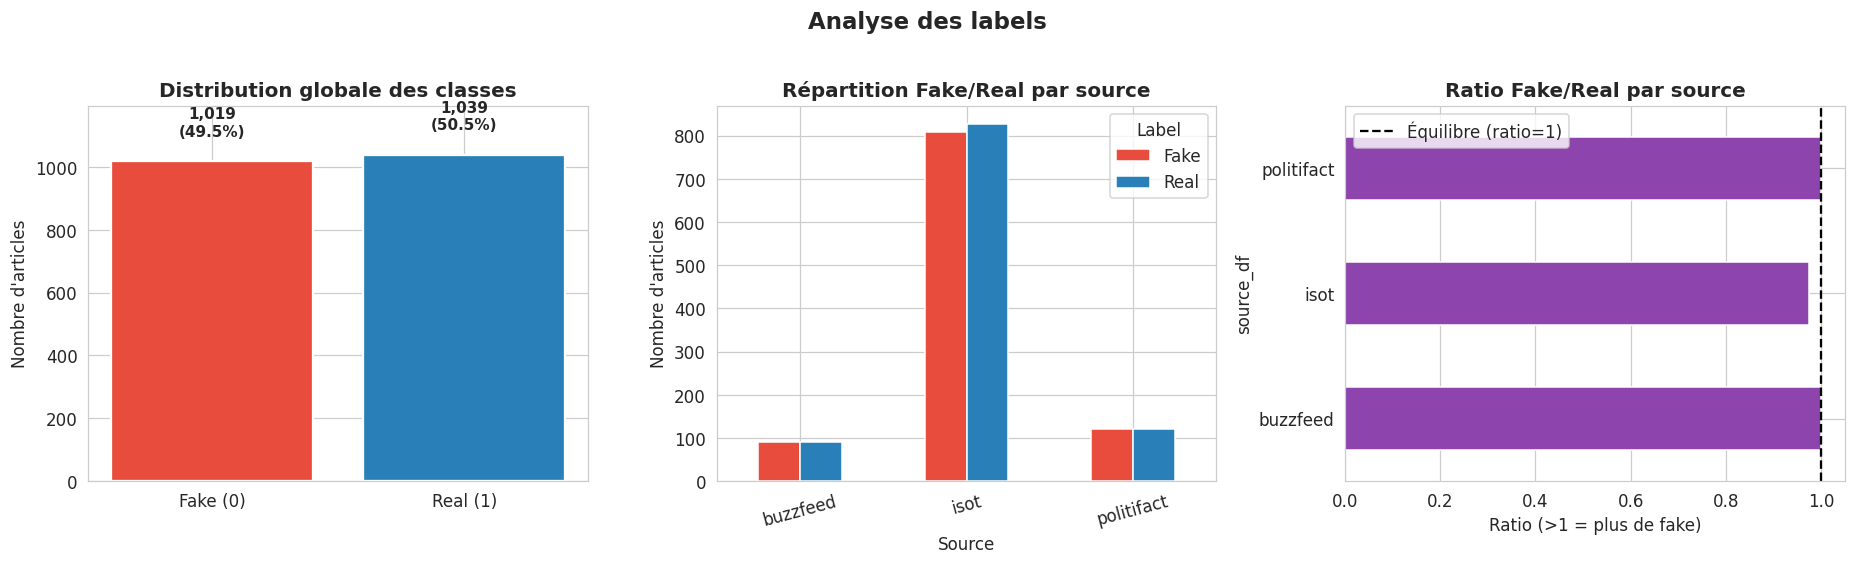


  Ratio déséquilibre (min/max) : 0.981
   → Dataset relativement équilibré.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── 4.1 Distribution globale des classes ──────────────────────────────────────
label_counts = df_raw["label"].value_counts().sort_index()
label_names  = ["Fake (0)", "Real (1)"]
colors       = ["#e74c3c", "#2980b9"]
bars = axes[0].bar(label_names, label_counts.values, color=colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, label_counts.values):
    pct = val / label_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Distribution globale des classes", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Nombre d'articles")
axes[0].set_ylim(0, label_counts.max() * 1.15)

# ── 4.2 Répartition par source ────────────────────────────────────────────────
src_label = df_raw.groupby(["source_df", "label"]).size().unstack(fill_value=0)
src_label.columns = ["Fake", "Real"]
src_label.plot(kind="bar", ax=axes[1], color=["#e74c3c", "#2980b9"],
               edgecolor="white", linewidth=1)
axes[1].set_title("Répartition Fake/Real par source", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Nombre d'articles")
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title="Label")

# ── 4.3 Ratio Fake/Real par source (déséquilibre) ────────────────────────────
src_ratio = src_label["Fake"] / (src_label["Real"] + 1e-9)
src_ratio.plot(kind="barh", ax=axes[2], color="#8e44ad", edgecolor="white")
axes[2].axvline(x=1.0, color="black", linestyle="--", linewidth=1.5, label="Équilibre (ratio=1)")
axes[2].set_title("Ratio Fake/Real par source", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Ratio (>1 = plus de fake)")
axes[2].legend()

plt.suptitle("Analyse des labels", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Déséquilibre
ratio = label_counts.min() / label_counts.max()
print(f"\n  Ratio déséquilibre (min/max) : {ratio:.3f}")
if ratio < 0.7:
    print("   → Déséquilibre détecté : utiliser class_weight='balanced' ou sur-/sous-échantillonnage.")
else:
    print("   → Dataset relativement équilibré.")

---
## 5. EDA — Analyse textuelle (longueur, mots, phrases)

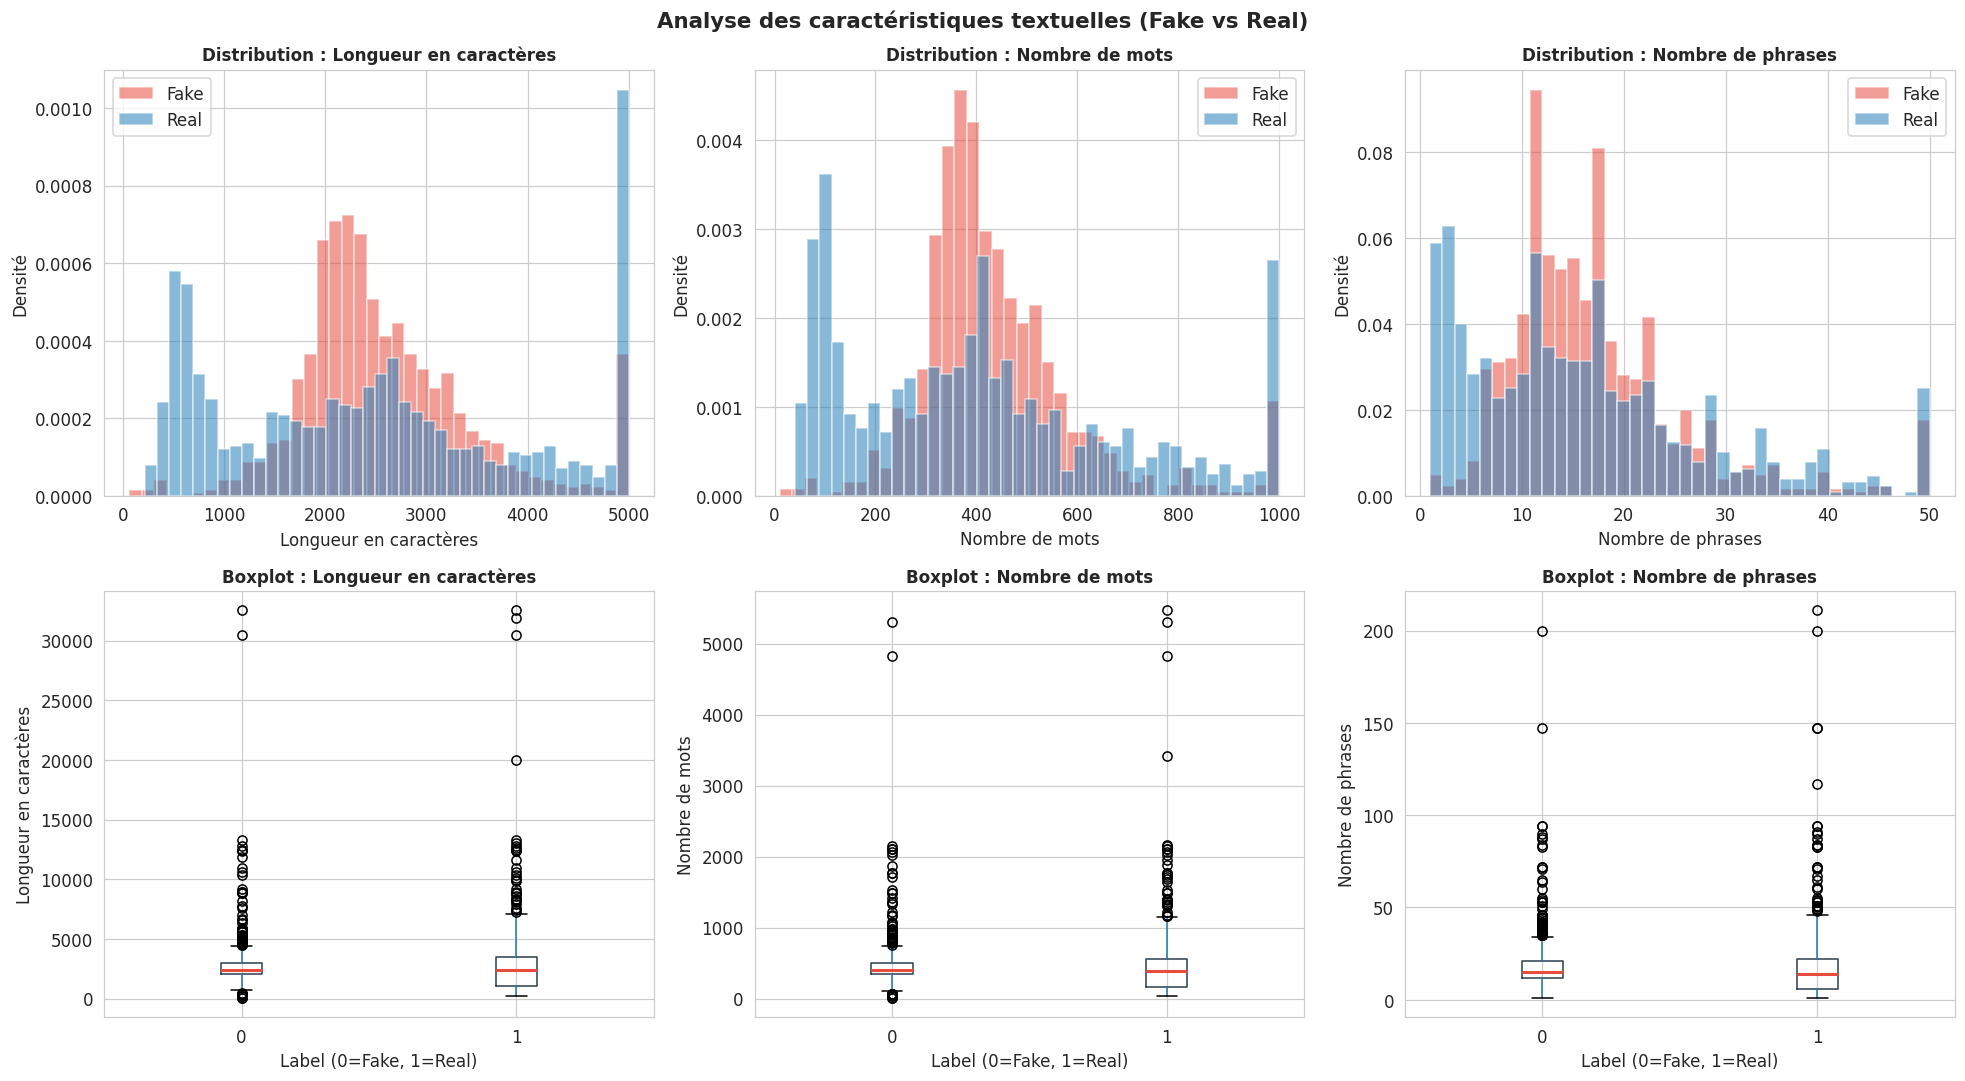


── Statistiques par label ──
      char_count                  word_count                sent_count         \
            mean  median      std       mean median     std       mean median   
label                                                                           
0        2750.95  2406.0  1847.19     459.03  404.0  299.38      17.96   15.0   
1        2743.17  2375.0  2601.37     443.60  381.0  427.01      17.21   14.0   

             avg_word_len               
         std         mean median   std  
label                                   
0      12.75         4.96   4.94  0.28  
1      17.15         5.20   5.20  0.28  


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    ("char_count",   "Longueur en caractères",  5000),
    ("word_count",   "Nombre de mots",          1000),
    ("sent_count",   "Nombre de phrases",       50),
]

for col_idx, (metric, title, clip_val) in enumerate(metrics):
    ax_hist = axes[0, col_idx]
    ax_box  = axes[1, col_idx]

    # Histogramme
    for lbl, color, name in [(0, "#e74c3c", "Fake"), (1, "#2980b9", "Real")]:
        data = df_raw[df_raw["label"] == lbl][metric].clip(upper=clip_val)
        ax_hist.hist(data, bins=40, alpha=0.55, color=color, label=name, density=True)
    ax_hist.set_title(f"Distribution : {title}", fontsize=11, fontweight="bold")
    ax_hist.set_xlabel(title)
    ax_hist.set_ylabel("Densité")
    ax_hist.legend()

    # Boxplot par label
    df_raw.boxplot(column=metric, by="label", ax=ax_box,
                   boxprops=dict(color="#2c3e50"),
                   medianprops=dict(color="#e74c3c", linewidth=2))
    ax_box.set_title(f"Boxplot : {title}", fontsize=11, fontweight="bold")
    ax_box.set_xlabel("Label (0=Fake, 1=Real)")
    ax_box.set_ylabel(title)

plt.suptitle("Analyse des caractéristiques textuelles (Fake vs Real)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Statistiques par label
print("\n── Statistiques par label ──")
print(df_raw.groupby("label")[["char_count", "word_count", "sent_count", "avg_word_len"]]
      .agg(["mean", "median", "std"]).round(2))

In [ ]:
# ── Articles trop courts ou trop longs ────────────────────────────────────────
SEUIL_MIN_MOTS = 10
SEUIL_MAX_MOTS = 5000

trop_courts = df_raw[df_raw["word_count"] < SEUIL_MIN_MOTS]
trop_longs  = df_raw[df_raw["word_count"] > SEUIL_MAX_MOTS]

print(f"Articles < {SEUIL_MIN_MOTS} mots  : {len(trop_courts)} ({len(trop_courts)/len(df_raw)*100:.2f}%)")
print(f"Articles > {SEUIL_MAX_MOTS} mots : {len(trop_longs)} ({len(trop_longs)/len(df_raw)*100:.2f}%)")

if not trop_courts.empty:
    print("\nExemples d'articles trop courts :")
    print(trop_courts[["statement", "label", "source_df"]].head(3).to_string())

Articles < 10 mots  : 0 (0.00%)
Articles > 5000 mots : 3 (0.15%)


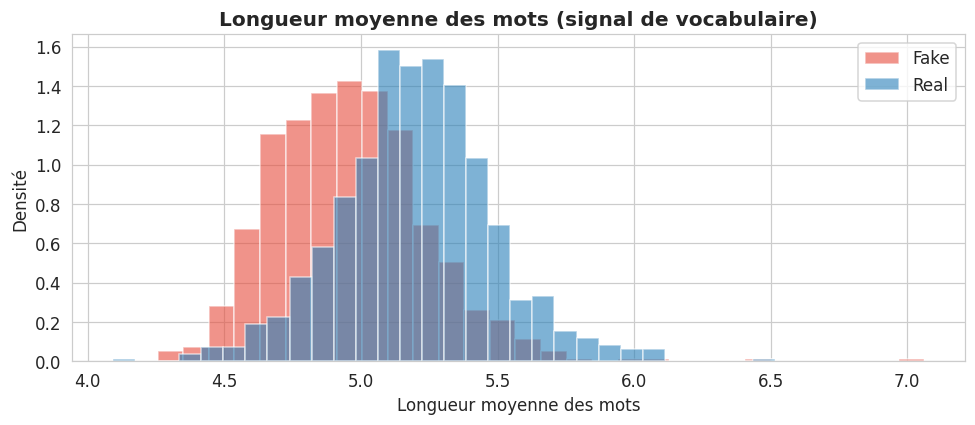

Longueur moy. mots — Fake : 4.958
Longueur moy. mots — Real : 5.201


In [ ]:
# ── Distribution longueur moyenne des mots ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
for lbl, color, name in [(0, "#e74c3c", "Fake"), (1, "#2980b9", "Real")]:
    data = df_raw[df_raw["label"] == lbl]["avg_word_len"]
    ax.hist(data, bins=30, alpha=0.6, color=color, label=name, density=True)
ax.set_title("Longueur moyenne des mots (signal de vocabulaire)", fontweight="bold")
ax.set_xlabel("Longueur moyenne des mots")
ax.set_ylabel("Densité")
ax.legend()
plt.tight_layout()
plt.show()

print("Longueur moy. mots — Fake :", df_raw[df_raw["label"]==0]["avg_word_len"].mean().round(3))
print("Longueur moy. mots — Real :", df_raw[df_raw["label"]==1]["avg_word_len"].mean().round(3))

---
## 6. EDA — Analyse cross-source (ISOT vs FakeNewsNet)

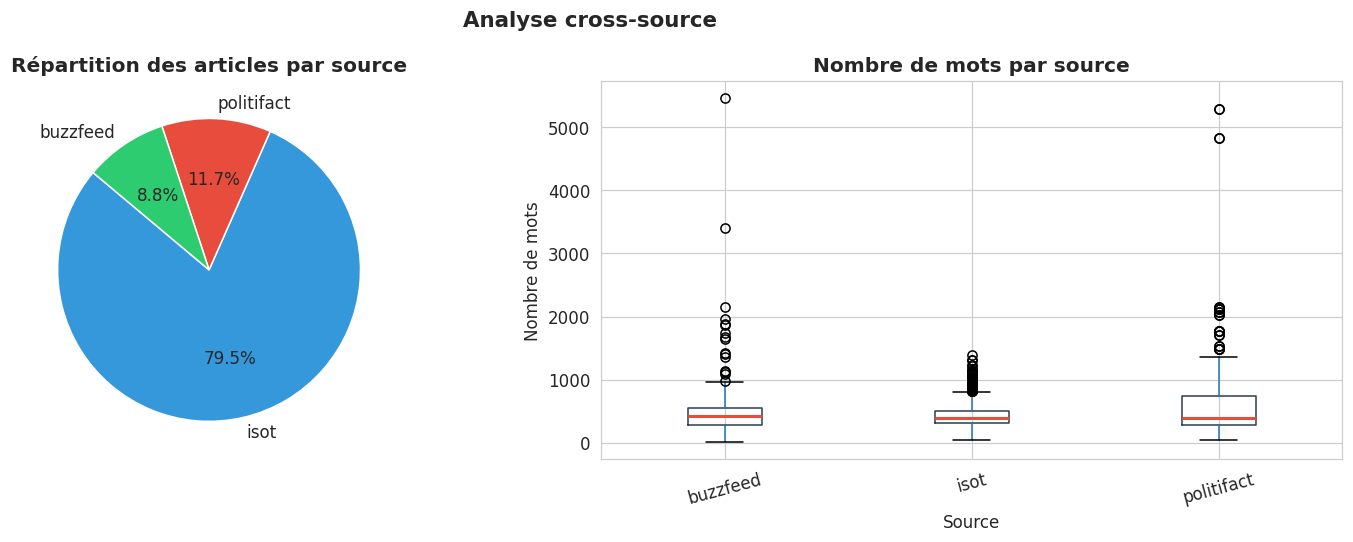


── Statistiques par source ──
           word_count              sent_count             
                 mean median count       mean median count
source_df                                                 
buzzfeed        541.4  414.5   182       23.8   18.0   182
isot            411.7  395.0  1636       15.4   14.0  1636
politifact      652.7  390.5   240       27.8   18.0   240


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Volume par source ─────────────────────────────────────────────────────────
src_counts = df_raw["source_df"].value_counts()
axes[0].pie(src_counts.values, labels=src_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=["#3498db", "#e74c3c", "#2ecc71", "#f39c12"])
axes[0].set_title("Répartition des articles par source", fontweight="bold")

# ── Longueur des textes par source ───────────────────────────────────────────
df_raw.boxplot(column="word_count", by="source_df", ax=axes[1],
               boxprops=dict(color="#2c3e50"),
               medianprops=dict(color="#e74c3c", linewidth=2))
axes[1].set_title("Nombre de mots par source", fontweight="bold")
axes[1].set_xlabel("Source")
axes[1].set_ylabel("Nombre de mots")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Analyse cross-source", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n── Statistiques par source ──")
print(df_raw.groupby("source_df")[["word_count", "sent_count"]]
      .agg(["mean", "median", "count"]).round(1))

In [ ]:
# ── Chevauchement vocabulaire ISOT vs FakeNewsNet ─────────────────────────────
def get_vocab(df_subset, n=10000):
    vec = CountVectorizer(max_features=n, stop_words="english")
    vec.fit(df_subset["statement"].fillna(""))
    return set(vec.vocabulary_.keys())

vocab_isot = get_vocab(df_raw[df_raw["source_df"] == "isot"])
vocab_fnn  = get_vocab(df_raw[df_raw["source_df"].isin(["buzzfeed", "politifact"])])

overlap = vocab_isot & vocab_fnn
union   = vocab_isot | vocab_fnn
jaccard = len(overlap) / len(union)

print(f"Vocabulaire ISOT         : {len(vocab_isot):,} mots")
print(f"Vocabulaire FakeNewsNet  : {len(vocab_fnn):,} mots")
print(f"Vocabulaire commun       : {len(overlap):,} mots")
print(f"Jaccard similarity       : {jaccard:.3f}")
print("\n  Un faible Jaccard indique un shift de domaine → évaluation cross-domain importante.")

Vocabulaire ISOT         : 10,000 mots
Vocabulaire FakeNewsNet  : 10,000 mots
Vocabulaire commun       : 6,159 mots
Jaccard similarity       : 0.445

  Un faible Jaccard indique un shift de domaine → évaluation cross-domain importante.


---
## 7. EDA — Analyse lexicale (TF-IDF, N-grams, Word clouds)

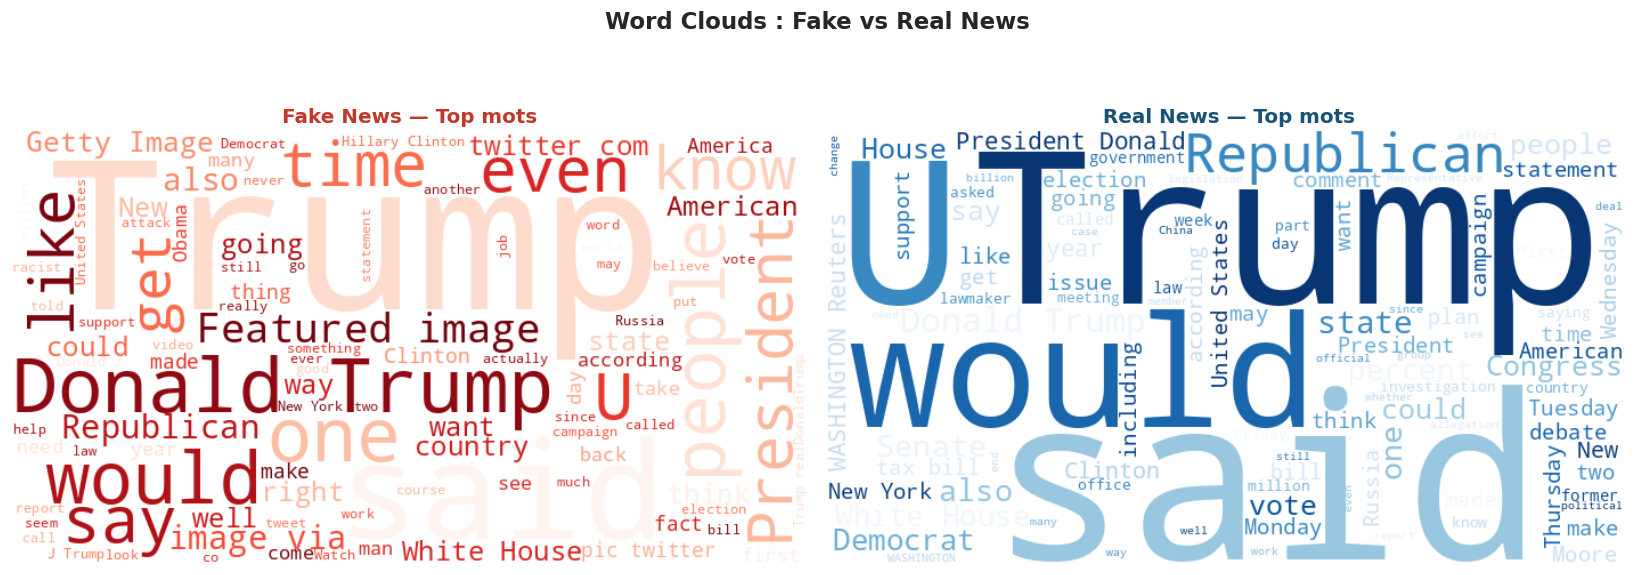

In [ ]:
# ── Word clouds ───────────────────────────────────────────────────────────────
fake_text = " ".join(df_raw[df_raw["label"] == 0]["statement"].fillna(""))
real_text = " ".join(df_raw[df_raw["label"] == 1]["statement"].fillna(""))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, text, title, color in zip(
    axes,
    [fake_text, real_text],
    ["Fake News — Top mots", " Real News — Top mots"],
    ["#c0392b", "#1a5276"]
):
    wc = WordCloud(
        width=700, height=380,
        background_color="white",
        stopwords=set(stopwords.words("english")),
        colormap="Reds" if "Fake" in title else "Blues",
        max_words=100
    ).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=13, fontweight="bold", color=color)
    ax.axis("off")

plt.suptitle("Word Clouds : Fake vs Real News", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

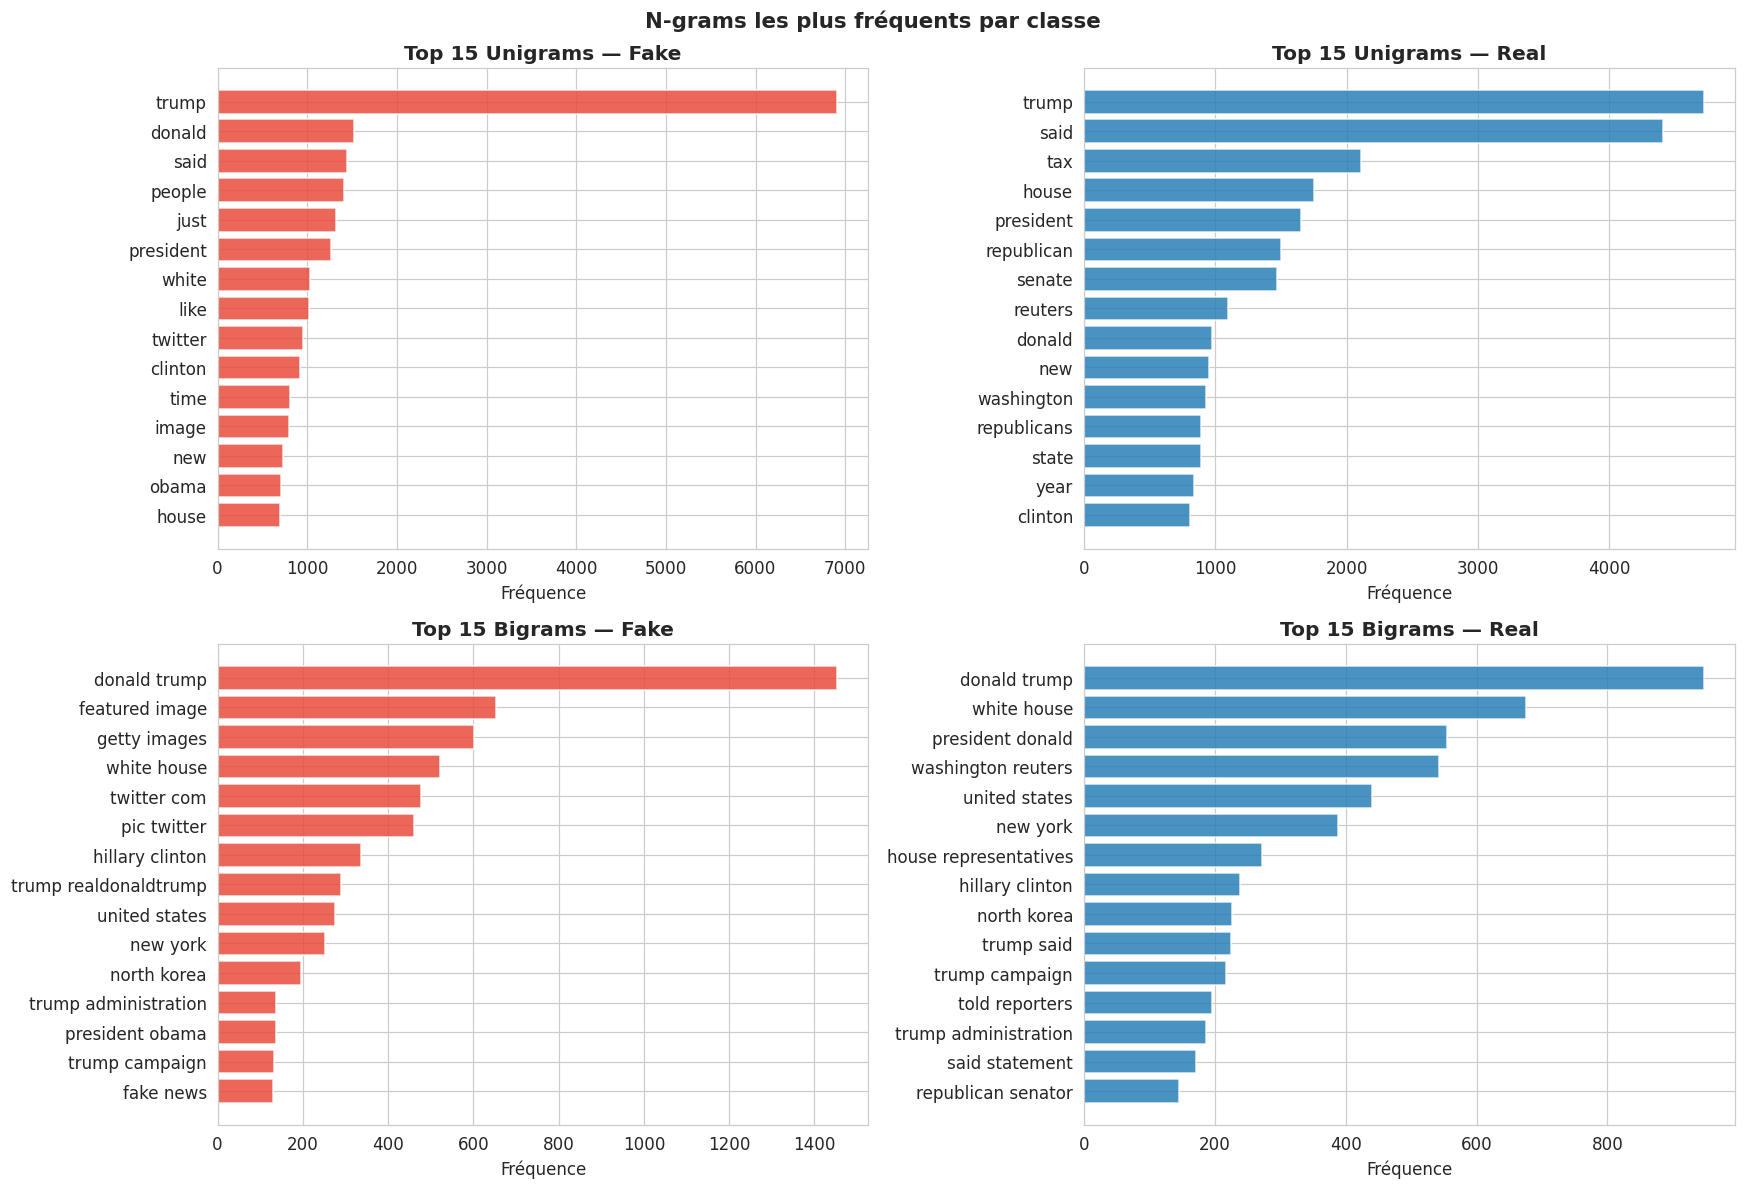

In [ ]:
# ── Top N-grams discriminants ─────────────────────────────────────────────────
def top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english", max_features=50000)
    X   = vec.fit_transform(corpus)
    freq = X.sum(axis=0).A1
    terms = vec.get_feature_names_out()
    df_ng = pd.DataFrame({"ngram": terms, "freq": freq})
    return df_ng.nlargest(top_k, "freq").reset_index(drop=True)

fake_corpus = df_raw[df_raw["label"] == 0]["statement"].fillna("")
real_corpus = df_raw[df_raw["label"] == 1]["statement"].fillna("")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for row, (n, label) in enumerate([(1, "Unigrams"), (2, "Bigrams")]):
    for col, (corpus, name, color) in enumerate([
        (fake_corpus, "Fake", "#e74c3c"),
        (real_corpus, "Real", "#2980b9")
    ]):
        ax   = axes[row, col]
        data = top_ngrams(corpus, n=n, top_k=15)
        ax.barh(data["ngram"][::-1], data["freq"][::-1], color=color, alpha=0.85)
        ax.set_title(f"Top 15 {label} — {name}", fontweight="bold")
        ax.set_xlabel("Fréquence")

plt.suptitle("N-grams les plus fréquents par classe", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

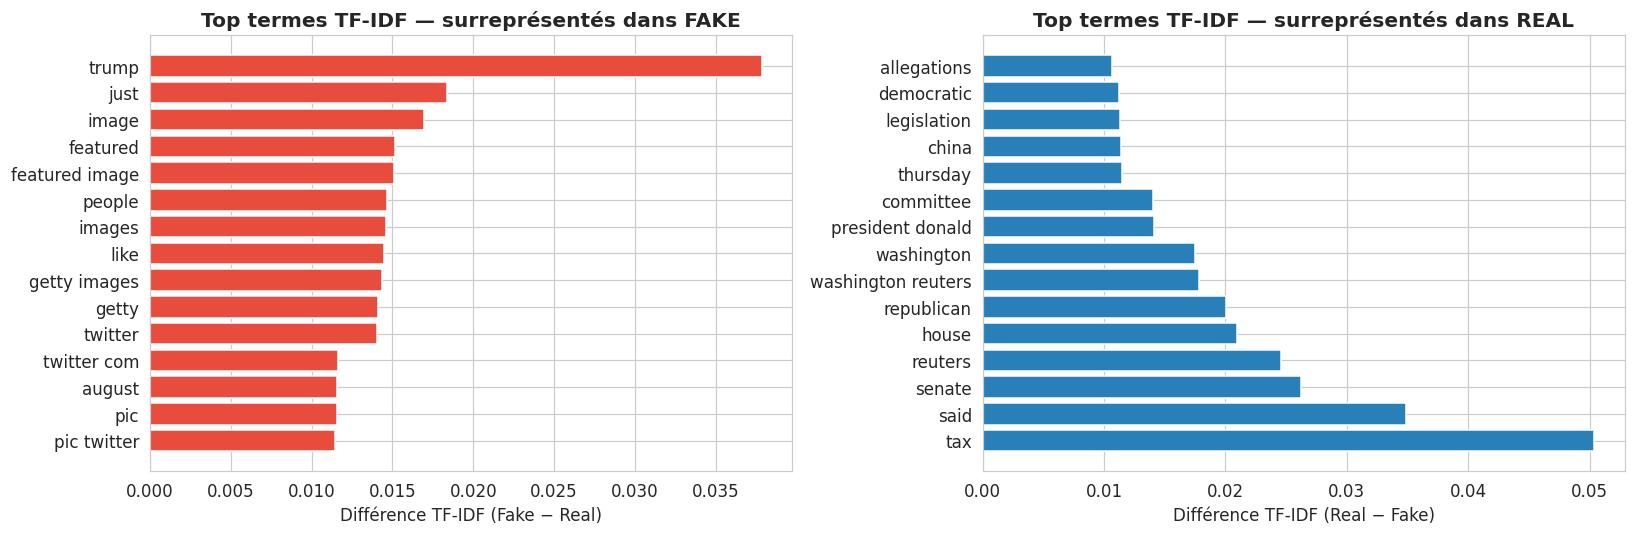

In [ ]:
# ── TF-IDF : mots les plus discriminants ─────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer

vec_tfidf = TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1,2))
X_all = vec_tfidf.fit_transform(df_raw["statement"].fillna(""))
terms = vec_tfidf.get_feature_names_out()

# Moyenne TF-IDF par classe
mask_fake = (df_raw["label"] == 0).values
mask_real = (df_raw["label"] == 1).values

mean_fake = X_all[mask_fake].mean(axis=0).A1
mean_real = X_all[mask_real].mean(axis=0).A1
diff      = mean_fake - mean_real  # positif → plus dans fake

top_fake_idx = np.argsort(diff)[-15:][::-1]
top_real_idx = np.argsort(diff)[:15]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh([terms[i] for i in top_fake_idx[::-1]], diff[top_fake_idx[::-1]], color="#e74c3c")
axes[0].set_title("Top termes TF-IDF — surreprésentés dans FAKE", fontweight="bold")
axes[0].set_xlabel("Différence TF-IDF (Fake − Real)")

axes[1].barh([terms[i] for i in top_real_idx], -diff[top_real_idx], color="#2980b9")
axes[1].set_title("Top termes TF-IDF — surreprésentés dans REAL", fontweight="bold")
axes[1].set_xlabel("Différence TF-IDF (Real − Fake)")

plt.tight_layout()
plt.show()

---
## 8. EDA — Qualité des données (NaN, doublons, bruit)

In [ ]:
print("═" * 55)
print(" RAPPORT DE QUALITÉ DES DONNÉES")
print("═" * 55)

# NaN
nan_counts = df_raw.isnull().sum()
nan_pct    = (nan_counts / len(df_raw) * 100).round(2)
print("\n1. Valeurs manquantes :")
print(pd.DataFrame({"NaN count": nan_counts, "NaN %": nan_pct})
      .query("`NaN count` > 0").to_string())

# Doublons
dupl_exact  = df_raw.duplicated(subset="statement").sum()
dupl_prefix = df_raw["statement"].str[:100].duplicated().sum()
print(f"\n2. Doublons (statement exact)  : {dupl_exact}")
print(f"   Quasi-doublons (100 premiers caractères) : {dupl_prefix}")

# Textes vides ou quasi-vides
empty    = df_raw["statement"].str.strip().eq("").sum()
very_short = (df_raw["word_count"] < 5).sum()
print(f"\n3. Textes vides (après strip)  : {empty}")
print(f"   Textes très courts (<5 mots) : {very_short}")

# Caractères spéciaux excessifs
df_raw["special_ratio"] = df_raw["statement"].apply(
    lambda x: sum(1 for c in str(x) if not c.isalnum() and c != ' ') / max(len(str(x)), 1)
)
noisy = (df_raw["special_ratio"] > 0.3).sum()
print(f"\n4. Textes très bruités (>30% car. spéciaux) : {noisy}")

# Textes encodés / HTML résiduel
html_pattern = re.compile(r'<[a-zA-Z][^>]*>')
has_html = df_raw["statement"].apply(lambda x: bool(html_pattern.search(str(x)))).sum()
print(f"\n5. Articles avec balises HTML résiduelles : {has_html}")

# URLs résiduelles
has_url = df_raw["statement"].str.contains(r'http|www\.', regex=True, na=False).sum()
print(f"\n6. Articles avec URLs résiduelles : {has_url}")

═══════════════════════════════════════════════════════
 RAPPORT DE QUALITÉ DES DONNÉES
═══════════════════════════════════════════════════════

1. Valeurs manquantes :
Empty DataFrame
Columns: [NaN count, NaN %]
Index: []

2. Doublons (statement exact)  : 135
   Quasi-doublons (100 premiers caractères) : 135

3. Textes vides (après strip)  : 0
   Textes très courts (<5 mots) : 0

4. Textes très bruités (>30% car. spéciaux) : 0

5. Articles avec balises HTML résiduelles : 1

6. Articles avec URLs résiduelles : 142


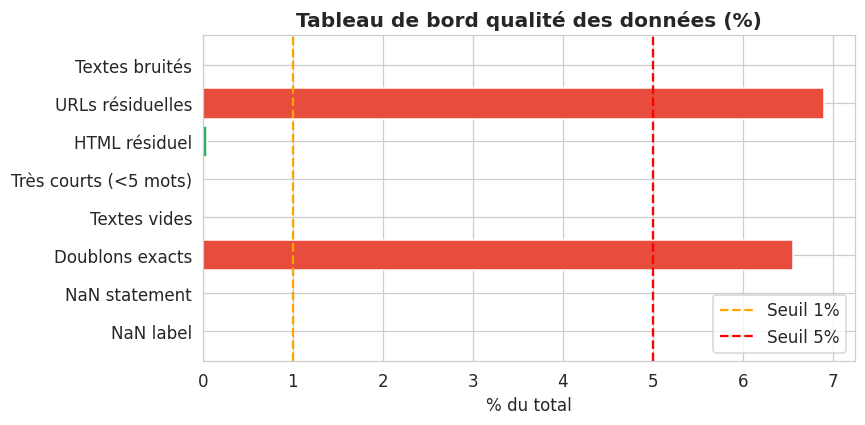

             Métrique  Nombre  % du total
            NaN label       0       0.000
        NaN statement       0       0.000
      Doublons exacts     135       6.560
         Textes vides       0       0.000
Très courts (<5 mots)       0       0.000
        HTML résiduel       1       0.049
     URLs résiduelles     142       6.900
       Textes bruités       0       0.000


In [ ]:
# ── Heatmap qualité des données ───────────────────────────────────────────────
quality_metrics = pd.DataFrame({
    "Métrique":  ["NaN label", "NaN statement", "Doublons exacts",
                  "Textes vides", "Très courts (<5 mots)",
                  "HTML résiduel", "URLs résiduelles", "Textes bruités"],
    "Nombre":    [
        df_raw["label"].isna().sum(),
        df_raw["statement"].isna().sum(),
        dupl_exact, empty, very_short,
        has_html, has_url, noisy
    ]
})
quality_metrics["% du total"] = (quality_metrics["Nombre"] / len(df_raw) * 100).round(3)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ["#27ae60" if v < 1 else ("#f39c12" if v < 5 else "#e74c3c")
              for v in quality_metrics["% du total"]]
ax.barh(quality_metrics["Métrique"], quality_metrics["% du total"], color=colors_bar)
ax.axvline(x=1, color="orange", linestyle="--", label="Seuil 1%")
ax.axvline(x=5, color="red",    linestyle="--", label="Seuil 5%")
ax.set_title("Tableau de bord qualité des données (%)", fontweight="bold")
ax.set_xlabel("% du total")
ax.legend()
plt.tight_layout()
plt.show()
print(quality_metrics.to_string(index=False))

---
## 9. Prétraitement — Pipeline NLP unifié

**Étapes :**
1. Suppression des doublons et NaN
2. Normalisation (minuscules, URLs, HTML, ponctuation)
3. Tokenisation
4. Filtrage stopwords + tokens trop courts
5. Lemmatisation guidée par POS tags
6. Reconstruction du texte

In [ ]:
# ── Nettoyage structurel ──────────────────────────────────────────────────────
df = df_raw.copy()

n_avant = len(df)
df.drop_duplicates(subset="statement", inplace=True)
df.dropna(subset=["statement", "label"], inplace=True)
df = df[df["word_count"] >= 5].copy()   # retirer textes quasi-vides
df.reset_index(drop=True, inplace=True)

print(f"Lignes avant nettoyage structurel : {n_avant}")
print(f"Lignes après nettoyage structurel : {len(df)}")
print(f"Supprimées : {n_avant - len(df)}")

Lignes avant nettoyage structurel : 2058
Lignes après nettoyage structurel : 1923
Supprimées : 135


In [ ]:
# ── Pipeline NLP ──────────────────────────────────────────────────────────────
STOP_WORDS  = set(stopwords.words("english"))
LEMMATIZER  = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag: str) -> str:
    """Mappe les tags Penn Treebank vers les catégories WordNet pour la lemmatisation."""
    from nltk.corpus import wordnet
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN   # défaut

def clean_text(text: str, use_pos_lemma: bool = True) -> str:

    # Étape 1 — Normalisation
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)     # URLs
    text = re.sub(r"<[^>]+>", " ", text)               # HTML
    text = re.sub(r"[^a-z\s]", " ", text)              # ponctuation / chiffres
    text = re.sub(r"\s+", " ", text).strip()

    # Étape 2 — Tokenisation
    tokens = word_tokenize(text)

    # Étape 3 — Filtrage
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # Étape 4 — Lemmatisation
    if use_pos_lemma:
        try:
            pos_tags  = pos_tag(tokens)
            tokens = [
                LEMMATIZER.lemmatize(word, get_wordnet_pos(tag))
                for word, tag in pos_tags
            ]
        except LookupError:
            # Fallback si le tagger POS n'est pas disponible
            tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    else:
        tokens = [LEMMATIZER.lemmatize(t) for t in tokens]

    return " ".join(tokens)

print(" Application du nettoyage sur tout le dataset (peut prendre quelques minutes)...")
df["clean"] = df["statement"].apply(clean_text)
print(f" Nettoyage terminé. {len(df)} articles traités.")

# Aperçu avant/après
print("\n── Exemple avant/après ──")
for i in range(2):
    print(f"\n[{i}] AVANT : {df['statement'].iloc[i][:150]}")
    print(f"[{i}] APRÈS : {df['clean'].iloc[i][:150]}")

 Application du nettoyage sur tout le dataset (peut prendre quelques minutes)...
 Nettoyage terminé. 1923 articles traités.

── Exemple avant/après ──

[0] AVANT :  Chuck Schumer Just NUKED Trump For Blaming Him For Terrorist Attack Donald Trump just got owned.On Tuesday, New York City was attacked by a terrorist
[0] APRÈS : chuck schumer nuked trump blaming terrorist attack donald trump got owned tuesday new york city attacked terrorist killed eight people truck police im

[1] AVANT :  Did Ron Paul Just Confuse Al-Qaeda With ISIS, Or Does He Simply Not Know The Difference? (TWEETS) Former Texas Congressman Ron Paul added yet more fu
[1] APRÈS : ron paul confuse qaeda isi simply know difference tweet former texas congressman ron paul added yet fuel argument older people stay away twitter eithe


---
## 10. Prétraitement — Validation & diagnostics post-nettoyage

In [ ]:
# ── Métriques post-nettoyage ──────────────────────────────────────────────────
df["clean_word_count"] = df["clean"].str.split().str.len()
df["clean_char_count"] = df["clean"].str.len()
df["vocab_richness"]   = df["clean"].apply(
    lambda x: len(set(x.split())) / max(len(x.split()), 1)  # Type-Token Ratio
)

print("── Statistiques post-nettoyage ──")
print(df.groupby("label")[["clean_word_count", "vocab_richness"]]
      .agg(["mean", "median"]).round(3))

# Taux de compression
avg_before = df["word_count"].mean()
avg_after  = df["clean_word_count"].mean()
print(f"\nMots moyens avant nettoyage : {avg_before:.1f}")
print(f"Mots moyens après nettoyage : {avg_after:.1f}")
print(f"Taux de compression         : {(1 - avg_after/avg_before)*100:.1f}%")

── Statistiques post-nettoyage ──
      clean_word_count        vocab_richness       
                  mean median           mean median
label                                              
0              239.987  222.0          0.704  0.709
1              255.327  222.0          0.675  0.671

Mots moyens avant nettoyage : 437.4
Mots moyens après nettoyage : 247.7
Taux de compression         : 43.4%


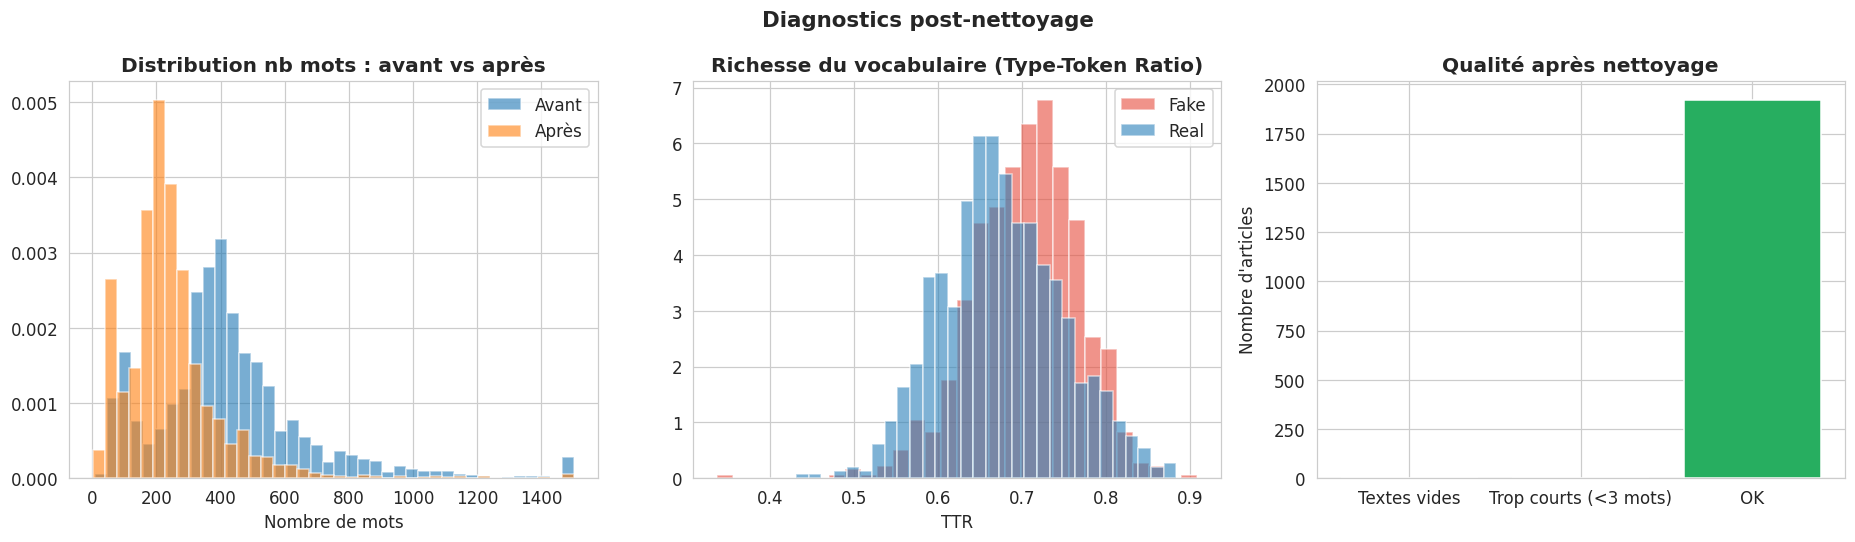


  Textes OK après nettoyage  : 1,923
  Textes vides après nettoyage : 0


In [ ]:
# ── Visualisations post-nettoyage ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Avant vs après — distribution des mots
for label, name in [("word_count", "Avant"), ("clean_word_count", "Après")]:
    axes[0].hist(df[label].clip(upper=1500), bins=40, alpha=0.6, label=name, density=True)
axes[0].set_title("Distribution nb mots : avant vs après", fontweight="bold")
axes[0].set_xlabel("Nombre de mots")
axes[0].legend()

# Type-Token Ratio par classe
for lbl, color, name in [(0, "#e74c3c", "Fake"), (1, "#2980b9", "Real")]:
    axes[1].hist(df[df["label"] == lbl]["vocab_richness"], bins=30,
                 alpha=0.6, color=color, label=name, density=True)
axes[1].set_title("Richesse du vocabulaire (Type-Token Ratio)", fontweight="bold")
axes[1].set_xlabel("TTR")
axes[1].legend()

# Textes vides après nettoyage
empty_after = (df["clean"].str.strip() == "").sum()
too_short   = (df["clean_word_count"] < 3).sum()
bar_data = {"Textes vides": empty_after, "Trop courts (<3 mots)": too_short,
            "OK": len(df) - empty_after - too_short}
axes[2].bar(bar_data.keys(), bar_data.values(),
            color=["#e74c3c", "#f39c12", "#27ae60"])
axes[2].set_title("Qualité après nettoyage", fontweight="bold")
axes[2].set_ylabel("Nombre d'articles")

plt.suptitle("Diagnostics post-nettoyage", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n  Textes OK après nettoyage  : {bar_data['OK']:,}")
print(f"  Textes vides après nettoyage : {empty_after}")

In [ ]:
# ── Suppression des textes trop courts après nettoyage ────────────────────────
df = df[df["clean_word_count"] >= 3].copy()
df.reset_index(drop=True, inplace=True)
print(f"Dataset final après filtrage post-nettoyage : {len(df):,} articles")
print(df["label"].value_counts())

Dataset final après filtrage post-nettoyage : 1,923 articles
label
1    972
0    951
Name: count, dtype: int64


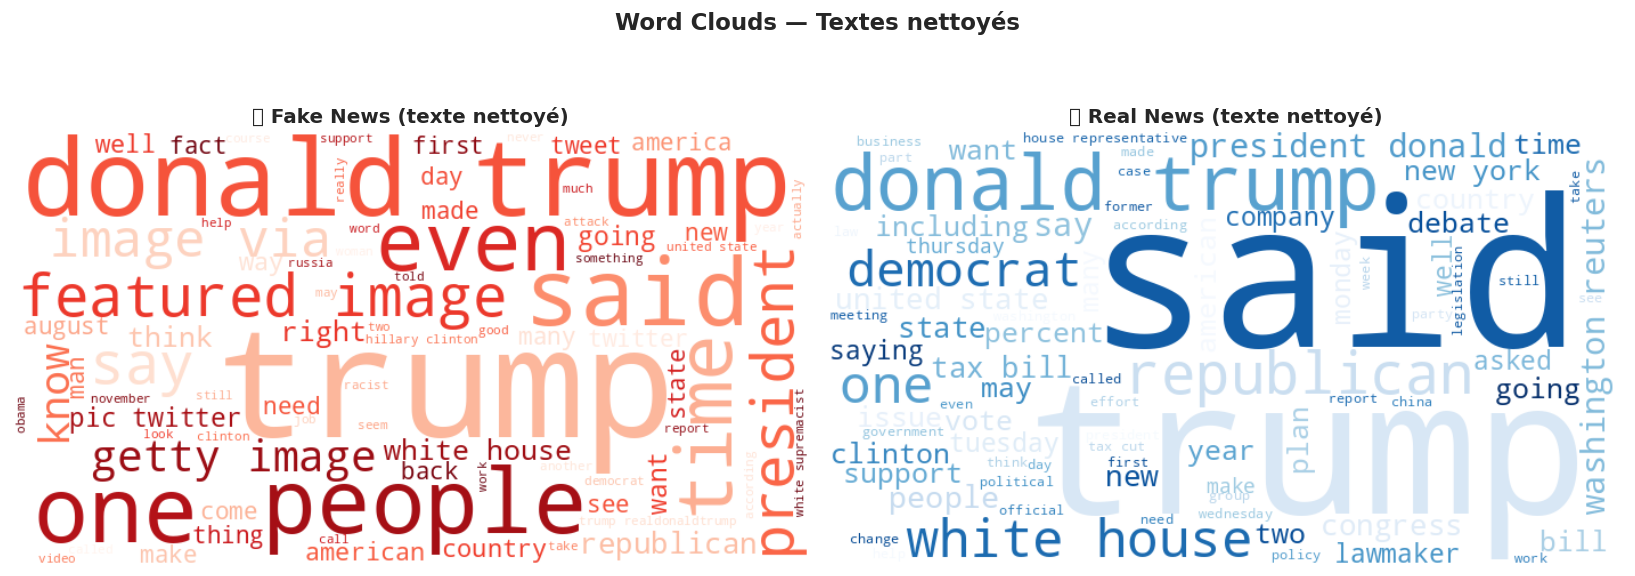

In [ ]:
# ── Word clouds post-nettoyage ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, lbl, title, cmap in zip(
    axes,
    [0, 1],
    ["🔴 Fake News (texte nettoyé)", "🔵 Real News (texte nettoyé)"],
    ["Reds", "Blues"]
):
    text = " ".join(df[df["label"] == lbl]["clean"].fillna(""))
    wc = WordCloud(width=700, height=380, background_color="white",
                   colormap=cmap, max_words=80).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")

plt.suptitle("Word Clouds — Textes nettoyés", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 11. Split train/test stratifié

In [ ]:
# ── Split stratifié 80/20 ─────────────────────────────────────────────────────
#  Le split se fait sur le texte NETTOYÉ, AVANT toute vectorisation.
#    Les vectoriseurs seront fittés UNIQUEMENT sur X_train.

X_train_text, X_test_text, y_train, y_test, idx_train, idx_test = train_test_split(
    df["clean"],
    df["label"],
    df.index,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print(f"Train : {len(X_train_text):,} articles")
print(f"Test  : {len(X_test_text):,} articles")
print(f"\nDistribution train — Fake: {(y_train==0).sum()} | Real: {(y_train==1).sum()}")
print(f"Distribution test  — Fake: {(y_test==0).sum()}  | Real: {(y_test==1).sum()}")

# Vérification de la stratification
ratio_train = (y_train == 0).sum() / len(y_train)
ratio_test  = (y_test  == 0).sum() / len(y_test)
print(f"\nRatio Fake — train: {ratio_train:.3f} | test: {ratio_test:.3f} ")

Train : 1,538 articles
Test  : 385 articles

Distribution train — Fake: 761 | Real: 777
Distribution test  — Fake: 190  | Real: 195

Ratio Fake — train: 0.495 | test: 0.494 


In [ ]:
# ── Validation : pas de data leakage ─────────────────────────────────────────
train_set = set(X_train_text.values)
test_set  = set(X_test_text.values)
overlap   = train_set & test_set
print(f"Chevauchement train/test (data leakage) : {len(overlap)} articles")
if len(overlap) == 0:
    print(" Aucun data leakage détecté.")
else:
    print("  Data leakage détecté ! Vérifier le pipeline de déduplication.")

Chevauchement train/test (data leakage) : 0 articles
 Aucun data leakage détecté.


---
## 12. Export du dataset prétraité

In [ ]:
# ── Export CSV ────────────────────────────────────────────────────────────────
df_export = df[["statement", "clean", "label", "source_df",
                "char_count", "word_count", "clean_word_count",
                "sent_count", "vocab_richness"]].copy()

# Ajout de la colonne split
df_export["split"] = "train"
df_export.loc[idx_test, "split"] = "test"

out_path = OUT_DIR / "truthguard_preprocessed.csv"
df_export.to_csv(out_path, index=False)

print(f" Dataset exporté : {out_path}")
print(f"   Dimensions     : {df_export.shape}")
print(f"   Colonnes       : {list(df_export.columns)}")
print(f"   Split train    : {(df_export['split'] == 'train').sum():,}")
print(f"   Split test     : {(df_export['split'] == 'test').sum():,}")
df_export.head(10)

 Dataset exporté : /content/drive/MyDrive/data/truthguard_preprocessed.csv
   Dimensions     : (1923, 10)
   Colonnes       : ['statement', 'clean', 'label', 'source_df', 'char_count', 'word_count', 'clean_word_count', 'sent_count', 'vocab_richness', 'split']
   Split train    : 1,538
   Split test     : 385


,statement,clean,label,source_df,char_count,word_count,clean_word_count,sent_count,vocab_richness,split
0,Chuck Schumer Just NUKED Trump For Blaming Hi...,chuck schumer nuked trump blaming terrorist at...,0,isot,2490,385,242,15,0.665289,train
1,"Did Ron Paul Just Confuse Al-Qaeda With ISIS,...",ron paul confuse qaeda isi simply know differe...,0,isot,2741,457,248,13,0.770161,test
2,Senator seeks explanation for career U.S. pros...,senator seek explanation career prosecutor abr...,1,isot,3303,515,313,21,0.619808,test
3,Liberal Group Trolls Trump At Roy Moore Rally...,liberal group troll trump roy moore rally best...,0,isot,2189,345,217,7,0.682028,train
4,"Ivanka Defends Malia Obama From Attacks, Her ...",ivanka defends malia obama attack dad fan stop...,0,isot,2697,439,253,21,0.612648,train
5,WATCH: Internet Hilariously Mocks Trump For N...,watch internet hilariously mock trump killing ...,0,isot,2711,454,256,14,0.671875,test
6,Trump administration releases rules on disclos...,trump administration release rule disclosing c...,1,isot,3972,621,359,23,0.671309,train
7,"Congress votes to avert shutdown, sends Trump ...",congress vote avert shutdown sends trump stopg...,1,isot,3491,557,327,19,0.688073,train
8,Michelle Obama NOT Leaving The White House – H...,michelle obama leaving white house hillary cli...,0,buzzfeed,2978,523,259,24,0.722008,train
9,Chaos Ensues After Man Accidentally Shoots Hi...,chaos ensues man accidentally shoot wife churc...,0,isot,2662,458,246,15,0.699187,train


In [ ]:
# ── Récapitulatif final ───────────────────────────────────────────────────────
print("═" * 60)
print(" RÉCAPITULATIF FINAL")
print("═" * 60)
print(f"\n  Dataset brut initial  : {n_avant:,} articles")
print(f"  Après dédoublonnage   : {len(df_raw):,} articles")
print(f"  Après nettoyage NLP   : {len(df):,} articles")
print(f"\n  Train                 : {len(X_train_text):,}")
print(f"  Test                  : {len(X_test_text):,}")
print(f"\n  Prochaine étape       : vectorisation TF-IDF + embeddings")
print(f"    Fitter les vectoriseurs UNIQUEMENT sur X_train_text")
print("="*60)

════════════════════════════════════════════════════════════
 RÉCAPITULATIF FINAL
════════════════════════════════════════════════════════════

  Dataset brut initial  : 2,058 articles
  Après dédoublonnage   : 2,058 articles
  Après nettoyage NLP   : 1,923 articles

  Train                 : 1,538
  Test                  : 385

  Prochaine étape       : vectorisation TF-IDF + embeddings
    Fitter les vectoriseurs UNIQUEMENT sur X_train_text


### Modélisation & Évaluation

---
## 13. Vectorisation TF-IDF (word + char n-grams)

In [ ]:
from scipy.sparse import hstack, csr_matrix
# ── Word-level TF-IDF ─────────────────────────────────────────────────────────
word_tfidf = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)
X_train_word = word_tfidf.fit_transform(X_train_text)   # fit UNIQUEMENT sur train
X_test_word  = word_tfidf.transform(X_test_text)

# ── Char-level TF-IDF ─────────────────────────────────────────────────────────
char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    max_features=5_000,
    ngram_range=(3, 5),
    sublinear_tf=True,
    min_df=2
)
X_train_char = char_tfidf.fit_transform(X_train_text)
X_test_char  = char_tfidf.transform(X_test_text)

# ── Combinaison TF-IDF ────────────────────────────────────────────────────────
X_train_tfidf = hstack([X_train_word, X_train_char])
X_test_tfidf  = hstack([X_test_word,  X_test_char])

print(f"TF-IDF (word+char) — Train : {X_train_tfidf.shape} | Test : {X_test_tfidf.shape}")

TF-IDF (word+char) — Train : (1538, 15000) | Test : (385, 15000)


---
## 14. Embeddings sémantiques (SentenceTransformer)

In [ ]:
from sentence_transformers import SentenceTransformer
CACHE_DIR = Path("/content/drive/MyDrive/cache_data")
EMBED_CACHE = CACHE_DIR / "embeddings_all.npy"
IDX_CACHE   = CACHE_DIR / "embeddings_idx.npy"

# Réindex global pour aligner embeddings ↔ df
df_indexed = df.reset_index(drop=True)
train_idx  = X_train_text.index
test_idx   = X_test_text.index

if EMBED_CACHE.exists():
    print(" Chargement des embeddings depuis le cache...")
    X_embeddings_all = np.load(EMBED_CACHE)
else:
    model_st = SentenceTransformer("all-MiniLM-L6-v2")
    X_embeddings_all = model_st.encode(
        df_indexed["statement"].fillna("").tolist(),
        show_progress_bar=True,
        batch_size=64
    )
    np.save(EMBED_CACHE, X_embeddings_all)
    print(f" Embeddings sauvegardés : {EMBED_CACHE}")

X_train_emb = X_embeddings_all[train_idx]
X_test_emb  = X_embeddings_all[test_idx]
print(f"Embeddings — Train : {X_train_emb.shape} | Test : {X_test_emb.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/31 [00:00<?, ?it/s]

 Embeddings sauvegardés : /content/drive/MyDrive/cache_data/embeddings_all.npy
Embeddings — Train : (1538, 384) | Test : (385, 384)


---
## 15. Features combinées TF-IDF + Embeddings

In [ ]:
X_train_full = hstack([X_train_tfidf, csr_matrix(X_train_emb)])
X_test_full  = hstack([X_test_tfidf,  csr_matrix(X_test_emb)])

print(f"Features combinées (TF-IDF + Embeddings)")
print(f"  Train : {X_train_full.shape}")
print(f"  Test  : {X_test_full.shape}")

# Mapping des représentations
FEATURE_SETS = {
    "TF-IDF seul":         (X_train_tfidf, X_test_tfidf),
    "Embeddings seul":     (csr_matrix(X_train_emb), csr_matrix(X_test_emb)),
    "TF-IDF + Embeddings": (X_train_full,  X_test_full),
}

Features combinées (TF-IDF + Embeddings)
  Train : (1538, 15384)
  Test  : (385, 15384)


---
## 16. Modèles baseline

Fonction d'évaluation unifiée + comparaison des représentations.

In [ ]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

# ── Fonction d'évaluation unifiée ─────────────────────────────────────────────
ALL_RESULTS  = []
ALL_PROBAS   = {}   # {nom_modèle: y_proba}

def evaluate_model(model, X_tr, y_tr, X_te, y_te,
                   model_name="Model", feature_set="TF-IDF + Embeddings",
                   show_cm=True, store=True):
    """Entraîne, évalue et stocke les résultats."""
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results = {
        "Model":        model_name,
        "Features":     feature_set,
        "Accuracy":     accuracy_score(y_te, y_pred),
        "Precision":    precision_score(y_te, y_pred, zero_division=0),
        "Recall":       recall_score(y_te, y_pred, zero_division=0),
        "F1":           f1_score(y_te, y_pred, zero_division=0),
        "AUC-ROC":      roc_auc_score(y_te, y_proba),
        "AUC-PR":       average_precision_score(y_te, y_proba),
        "Train time(s)":round(train_time, 2),
    }

    print(f"\n── {model_name} [{feature_set}] ──")
    for k, v in results.items():
        if k not in ["Model", "Features"]:
            print(f"  {k:16s}: {v:.4f}" if isinstance(v, float) else f"  {k:16s}: {v}")

    if show_cm:
        cm = confusion_matrix(y_te, y_pred)
        fig, ax = plt.subplots(figsize=(4, 3.5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=["Fake","Real"], yticklabels=["Fake","Real"], ax=ax)
        ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
        ax.set_title(f"Confusion Matrix — {model_name}")
        plt.tight_layout(); plt.show()

    if store:
        ALL_RESULTS.append(results)
        ALL_PROBAS[model_name] = y_proba

    return model, results, y_proba

print(" Fonction evaluate_model prête.")

 Fonction evaluate_model prête.



── Logistic Regression [TF-IDF + Embeddings] ──
  Accuracy        : 0.9351
  Precision       : 0.9381
  Recall          : 0.9333
  F1              : 0.9357
  AUC-ROC         : 0.9699
  AUC-PR          : 0.9733
  Train time(s)   : 1.1700


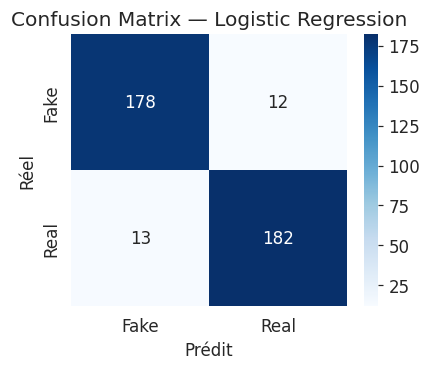

In [ ]:
from sklearn.linear_model import LogisticRegression

# ── 16.1 Logistic Regression ───────────────────────────────────────────────────
lr_model, lr_res, y_proba_lr = evaluate_model(
    LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0, random_state=SEED),
    X_train_full, y_train, X_test_full, y_test,
    model_name="Logistic Regression"
)


── SVM (calibré) [TF-IDF + Embeddings] ──
  Accuracy        : 0.9377
  Precision       : 0.9385
  Recall          : 0.9385
  F1              : 0.9385
  AUC-ROC         : 0.9732
  AUC-PR          : 0.9725
  Train time(s)   : 1.0600


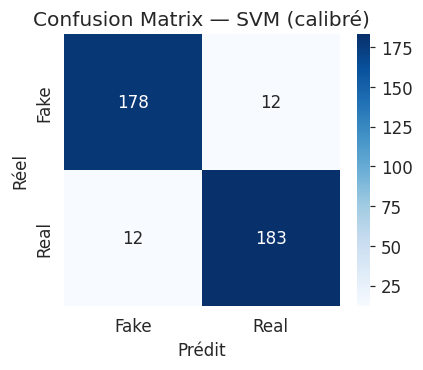

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

# ── 16.2 SVM Linéaire (calibré pour les probas) ────────────────────────────────
svm_model, svm_res, y_proba_svm = evaluate_model(
    CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", C=1.0, random_state=SEED), cv=5
    ),
    X_train_full, y_train, X_test_full, y_test,
    model_name="SVM (calibré)"
)


── Random Forest [TF-IDF + Embeddings] ──
  Accuracy        : 0.9221
  Precision       : 0.9231
  Recall          : 0.9231
  F1              : 0.9231
  AUC-ROC         : 0.9811
  AUC-PR          : 0.9848
  Train time(s)   : 12.0700


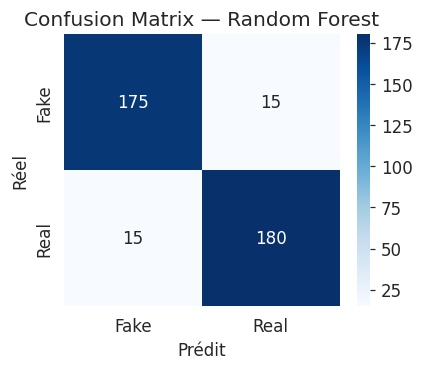

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ── 16.3 Random Forest ─────────────────────────────────────────────────────────
rf_model, rf_res, y_proba_rf = evaluate_model(
    RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        max_depth=None, min_samples_leaf=2, random_state=SEED, n_jobs=-1
    ),
    X_train_full, y_train, X_test_full, y_test,
    model_name="Random Forest"
)


── Complement Naive Bayes [TF-IDF seul] ──
  Accuracy        : 0.9169
  Precision       : 0.9358
  Recall          : 0.8974
  F1              : 0.9162
  AUC-ROC         : 0.9544
  AUC-PR          : 0.9635
  Train time(s)   : 0.1900


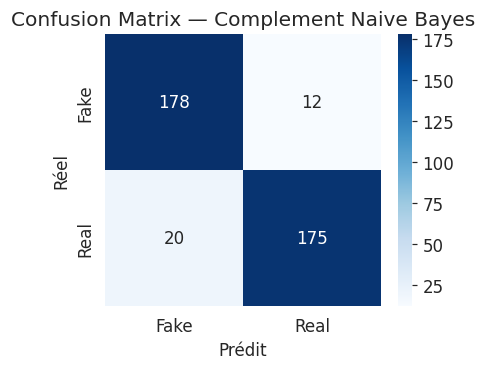

In [ ]:
# ── 16.4 Complement Naive Bayes (adapté texte déséquilibré) ────────────────────
cnb_model, cnb_res, y_proba_cnb = evaluate_model(
    CalibratedClassifierCV(ComplementNB(alpha=0.1), cv=5),
    X_train_tfidf, y_train, X_test_tfidf, y_test,
    model_name="Complement Naive Bayes",
    feature_set="TF-IDF seul"
)


═══ Comparaison des représentations (LR) ═══

── LR [TF-IDF seul] ──
  Accuracy        : 0.9377
  Precision       : 0.9340
  Recall          : 0.9436
  F1              : 0.9388
  AUC-ROC         : 0.9724
  AUC-PR          : 0.9778
  Train time(s)   : 0.2000

── LR [Embeddings seul] ──
  Accuracy        : 0.8727
  Precision       : 0.8763
  Recall          : 0.8718
  F1              : 0.8740
  AUC-ROC         : 0.9273
  AUC-PR          : 0.9307
  Train time(s)   : 0.1000

── LR [TF-IDF + Embeddings] ──
  Accuracy        : 0.9351
  Precision       : 0.9381
  Recall          : 0.9333
  F1              : 0.9357
  AUC-ROC         : 0.9699
  AUC-PR          : 0.9733
  Train time(s)   : 0.5200
                     Accuracy      F1  AUC-ROC
Features                                      
TF-IDF seul            0.9377  0.9388   0.9724
Embeddings seul        0.8727  0.8740   0.9273
TF-IDF + Embeddings    0.9351  0.9357   0.9699


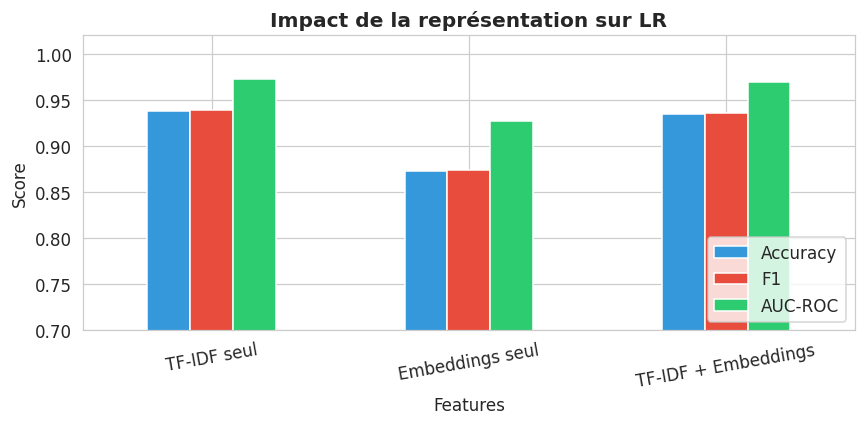

In [ ]:
# ── 16.5 Comparaison représentations sur Logistic Regression ───────────────────
print("\n═══ Comparaison des représentations (LR) ═══")
repr_results = []
for feat_name, (X_tr, X_te) in FEATURE_SETS.items():
    m = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    _, res, _ = evaluate_model(m, X_tr, y_train, X_te, y_test,
                               model_name="LR", feature_set=feat_name,
                               show_cm=False, store=False)
    repr_results.append(res)

repr_df = pd.DataFrame(repr_results).set_index("Features")
print(repr_df[["Accuracy","F1","AUC-ROC"]].round(4))

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
repr_df[["Accuracy","F1","AUC-ROC"]].plot(kind="bar", ax=ax,
    color=["#3498db","#e74c3c","#2ecc71"], edgecolor="white")
ax.set_title("Impact de la représentation sur LR", fontweight="bold")
ax.set_ylabel("Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=10)
ax.set_ylim(0.7, 1.02)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
## 17. Modèles avancés (XGBoost, LightGBM)


── XGBoost [TF-IDF + Embeddings] ──
  Accuracy        : 0.9273
  Precision       : 0.9154
  Recall          : 0.9436
  F1              : 0.9293
  AUC-ROC         : 0.9812
  AUC-PR          : 0.9858
  Train time(s)   : 233.2200


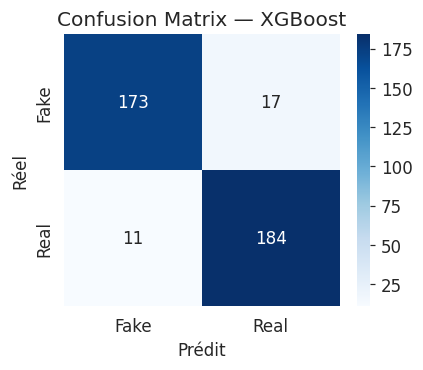


── LightGBM [TF-IDF + Embeddings] ──
  Accuracy        : 0.9299
  Precision       : 0.9286
  Recall          : 0.9333
  F1              : 0.9309
  AUC-ROC         : 0.9811
  AUC-PR          : 0.9857
  Train time(s)   : 198.9000


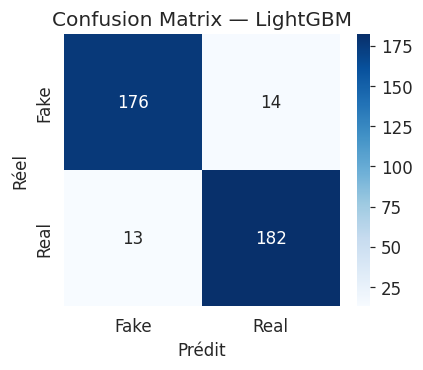

In [ ]:
import xgboost as xgb
import lightgbm as lgb

HAS_BOOST = True # Added this line

if HAS_BOOST:
    # Calcul du scale_pos_weight pour le déséquilibre
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    spw = neg / pos

    # ── XGBoost ───────────────────────────────────────────────────────────────
    xgb_model, xgb_res, y_proba_xgb = evaluate_model(
        xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            scale_pos_weight=spw, use_label_encoder=False,
            eval_metric="logloss", random_state=SEED, n_jobs=-1, verbosity=0
        ),
        X_train_full, y_train, X_test_full, y_test,
        model_name="XGBoost"
    )

    # ── LightGBM ──────────────────────────────────────────────────────────────
    lgb_model, lgb_res, y_proba_lgb = evaluate_model(
        lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05, num_leaves=63,
            scale_pos_weight=spw, random_state=SEED, n_jobs=-1, verbose=-1
        ),
        X_train_full, y_train, X_test_full, y_test,
        model_name="LightGBM"
    )
else:
    print(" XGBoost/LightGBM non disponibles, section ignorée.")

---
## 18. Stacking Ensemble — TruthGuard

Méta-modèle entraîné sur les probabilités out-of-fold des modèles de base.

 Entraînement du stacking (5 folds × 3 modèles)...
  Fold 5/5 terminé.
═══ TruthGuard (Stacking) ═══
  Accuracy        : 0.9377
  Precision       : 0.9340
  Recall          : 0.9436
  F1              : 0.9388
  AUC-ROC         : 0.9813
  AUC-PR          : 0.9858


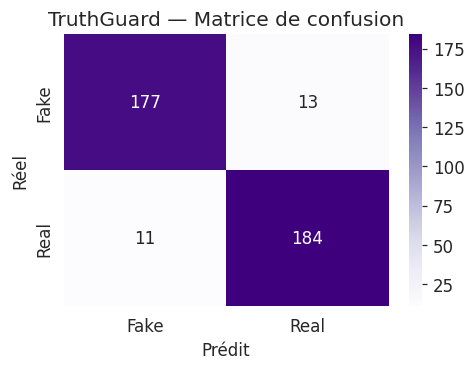

In [ ]:
from sklearn.model_selection import StratifiedKFold

def truthguard_stacking(base_models, meta_model, X_tr, y_tr, X_te, y_te,
                        n_splits=5, model_names=None):
    """
    Stacking avec StratifiedKFold.
    Génère les méta-features via OOF (out-of-fold) pour éviter le data leakage.
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    n_base   = len(base_models)
    names    = model_names or [f"Base_{i}" for i in range(n_base)]

    train_meta      = np.zeros((X_tr.shape[0], n_base))
    test_meta_folds = np.zeros((n_splits, X_te.shape[0], n_base))

    for fold_i, (tr_idx, val_idx) in enumerate(skf.split(X_tr, y_tr)):
        X_fold_tr  = X_tr[tr_idx]
        X_fold_val = X_tr[val_idx]
        y_fold_tr  = y_tr.iloc[tr_idx]

        for j, (model, name) in enumerate(zip(base_models, names)):
            model.fit(X_fold_tr, y_fold_tr)
            train_meta[val_idx, j]       = model.predict_proba(X_fold_val)[:, 1]
            test_meta_folds[fold_i, :, j]= model.predict_proba(X_te)[:, 1]

        print(f"  Fold {fold_i+1}/{n_splits} terminé.", end="\r")

    test_meta = test_meta_folds.mean(axis=0)

    # Entraîner le méta-modèle
    meta_model.fit(train_meta, y_tr)
    y_pred  = meta_model.predict(test_meta)
    y_proba = meta_model.predict_proba(test_meta)[:, 1]

    results = {
        "Model":     "TruthGuard (Stacking)",
        "Features":  "TF-IDF + Embeddings",
        "Accuracy":  accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall":    recall_score(y_te, y_pred, zero_division=0),
        "F1":        f1_score(y_te, y_pred, zero_division=0),
        "AUC-ROC":   roc_auc_score(y_te, y_proba),
        "AUC-PR":    average_precision_score(y_te, y_proba),
        "Train time(s)": 0,
    }

    print("\n═══ TruthGuard (Stacking) ═══")
    for k, v in results.items():
        if k not in ["Model", "Features", "Train time(s)"]:
            print(f"  {k:16s}: {v:.4f}")

    # Matrice de confusion
    fig, ax = plt.subplots(figsize=(4.5, 3.5))
    sns.heatmap(confusion_matrix(y_te, y_pred), annot=True, fmt="d", cmap="Purples",
                xticklabels=["Fake","Real"], yticklabels=["Fake","Real"], ax=ax)
    ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
    ax.set_title("TruthGuard — Matrice de confusion")
    plt.tight_layout(); plt.show()

    return meta_model, results, y_proba, train_meta, test_meta


# ── Instanciation des modèles de base ─────────────────────────────────────────
base_lr  = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
base_rf  = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                   random_state=SEED, n_jobs=-1)
base_svm = CalibratedClassifierCV(
    LinearSVC(class_weight="balanced", random_state=SEED), cv=3
)
meta_lr  = LogisticRegression(class_weight="balanced", random_state=SEED)

print(" Entraînement du stacking (5 folds × 3 modèles)...")
tg_meta, tg_res, y_proba_tg, train_meta, test_meta = truthguard_stacking(
    [base_lr, base_rf, base_svm], meta_lr,
    X_train_full, y_train, X_test_full, y_test,
    model_names=["LR", "RF", "SVM"]
)
ALL_RESULTS.append(tg_res)
ALL_PROBAS["TruthGuard (Stacking)"] = y_proba_tg

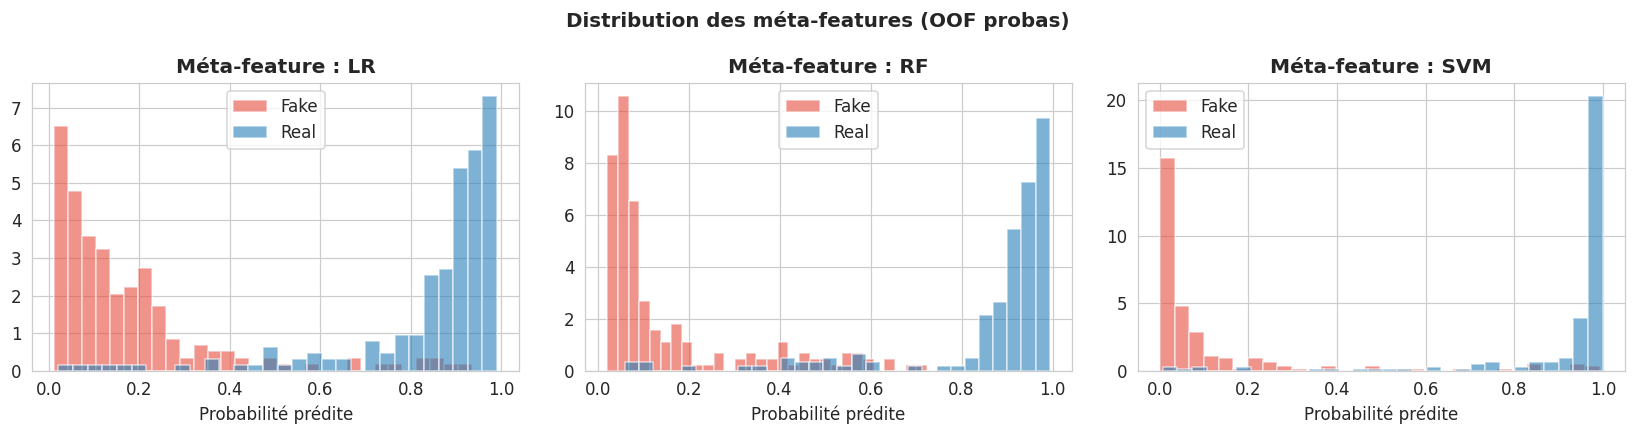

In [ ]:
# ── Visualisation méta-features du stacking ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
base_names = ["LR", "RF", "SVM"]

for i, (ax, name) in enumerate(zip(axes, base_names)):
    for lbl, color, lab in [(0, "#e74c3c", "Fake"), (1, "#2980b9", "Real")]:
        mask = y_test.values == lbl
        ax.hist(test_meta[mask, i], bins=30, alpha=0.6, color=color, label=lab, density=True)
    ax.set_title(f"Méta-feature : {name}", fontweight="bold")
    ax.set_xlabel("Probabilité prédite")
    ax.legend()

plt.suptitle("Distribution des méta-features (OOF probas)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 19. Comparaison globale des modèles

In [ ]:
results_df = pd.DataFrame(ALL_RESULTS)
print(results_df[["Model","Accuracy","Precision","Recall","F1","AUC-ROC","AUC-PR"]]
      .round(4).to_string(index=False))

                 Model  Accuracy  Precision  Recall     F1  AUC-ROC  AUC-PR
         Random Forest    0.9221     0.9231  0.9231 0.9231   0.9811  0.9848
Complement Naive Bayes    0.9169     0.9358  0.8974 0.9162   0.9544  0.9635
Complement Naive Bayes    0.9169     0.9358  0.8974 0.9162   0.9544  0.9635
Complement Naive Bayes    0.9169     0.9358  0.8974 0.9162   0.9544  0.9635
Complement Naive Bayes    0.9169     0.9358  0.8974 0.9162   0.9544  0.9635
               XGBoost    0.9273     0.9154  0.9436 0.9293   0.9812  0.9858
              LightGBM    0.9299     0.9286  0.9333 0.9309   0.9811  0.9857
 TruthGuard (Stacking)    0.9377     0.9340  0.9436 0.9388   0.9813  0.9858
 TruthGuard (Stacking)    0.9377     0.9340  0.9436 0.9388   0.9813  0.9858


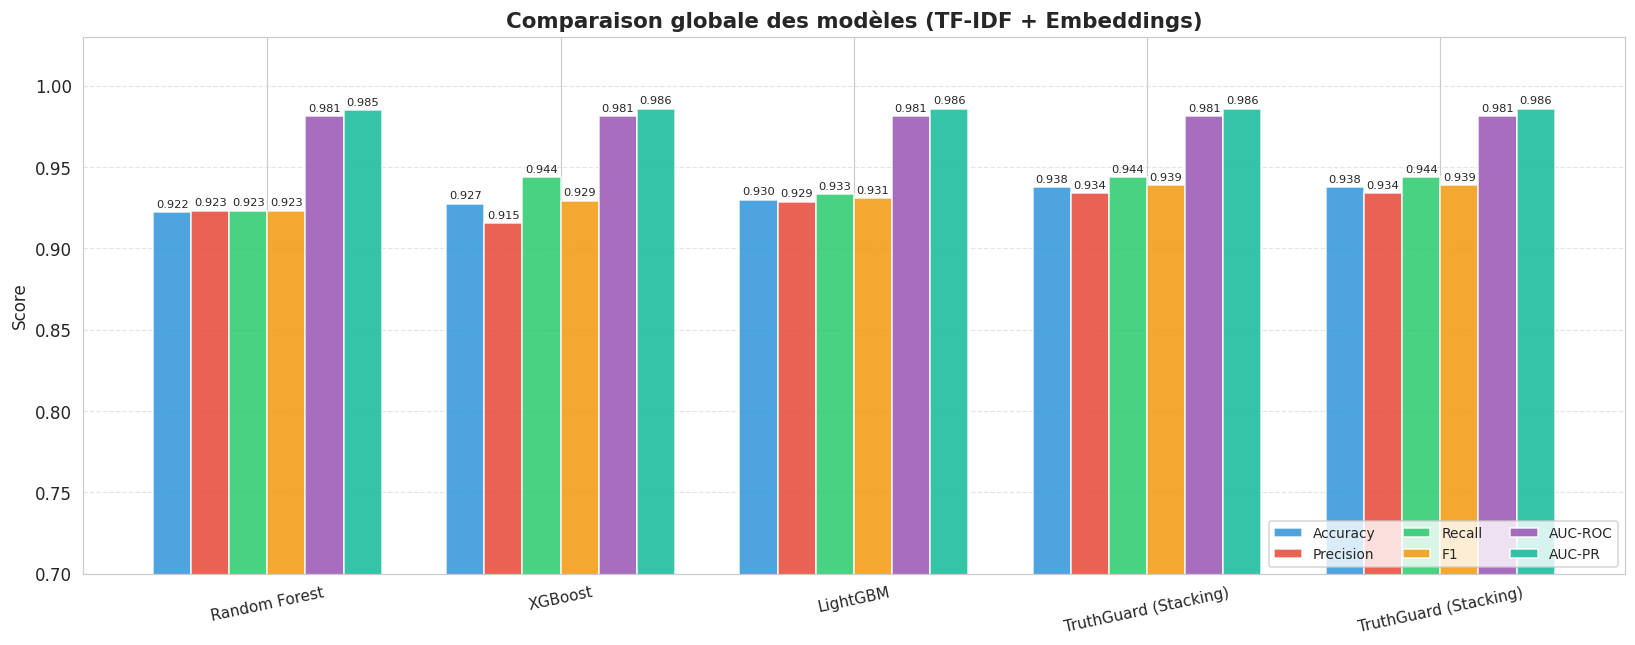

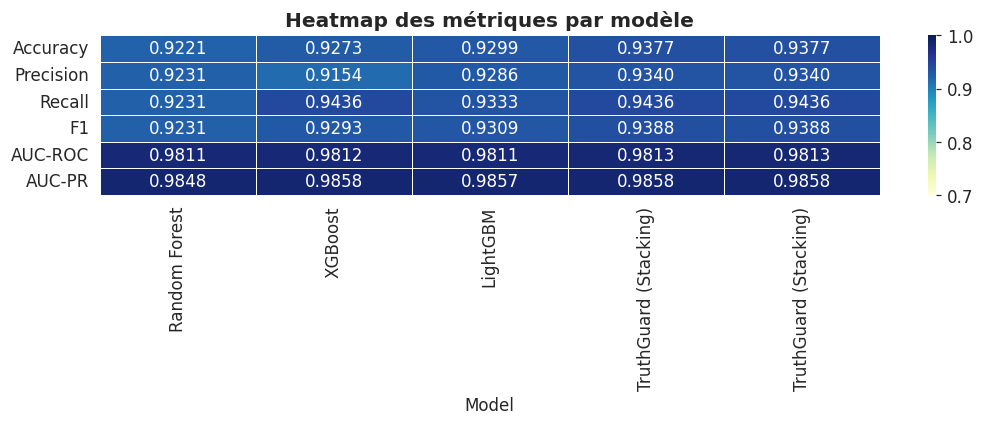

In [ ]:
# ── Graphe comparatif multi-métriques ─────────────────────────────────────────
# Filtrer sur features combinées pour une comparaison équitable
df_cmp = results_df[results_df["Features"] == "TF-IDF + Embeddings"].set_index("Model")

metrics  = ["Accuracy","Precision","Recall","F1","AUC-ROC","AUC-PR"]
x        = np.arange(len(df_cmp))
width    = 0.13
palette  = ["#3498db","#e74c3c","#2ecc71","#f39c12","#9b59b6","#1abc9c"]

fig, ax = plt.subplots(figsize=(15, 6))
for i, (metric, color) in enumerate(zip(metrics, palette)):
    bars = ax.bar(x + (i - 2.5) * width, df_cmp[metric], width,
                  label=metric, color=color, alpha=0.88, edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(df_cmp.index, rotation=12, fontsize=10)
ax.set_ylim(0.70, 1.03)
ax.set_ylabel("Score")
ax.set_title("Comparaison globale des modèles (TF-IDF + Embeddings)",
             fontsize=14, fontweight="bold")
ax.legend(ncol=3, loc="lower right", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Heatmap des métriques
fig, ax = plt.subplots(figsize=(10, 4))
heat_data = df_cmp[metrics].T
sns.heatmap(heat_data, annot=True, fmt=".4f", cmap="YlGnBu",
            vmin=0.7, vmax=1.0, linewidths=0.5, ax=ax)
ax.set_title("Heatmap des métriques par modèle", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 20. Courbes ROC & Precision-Recall

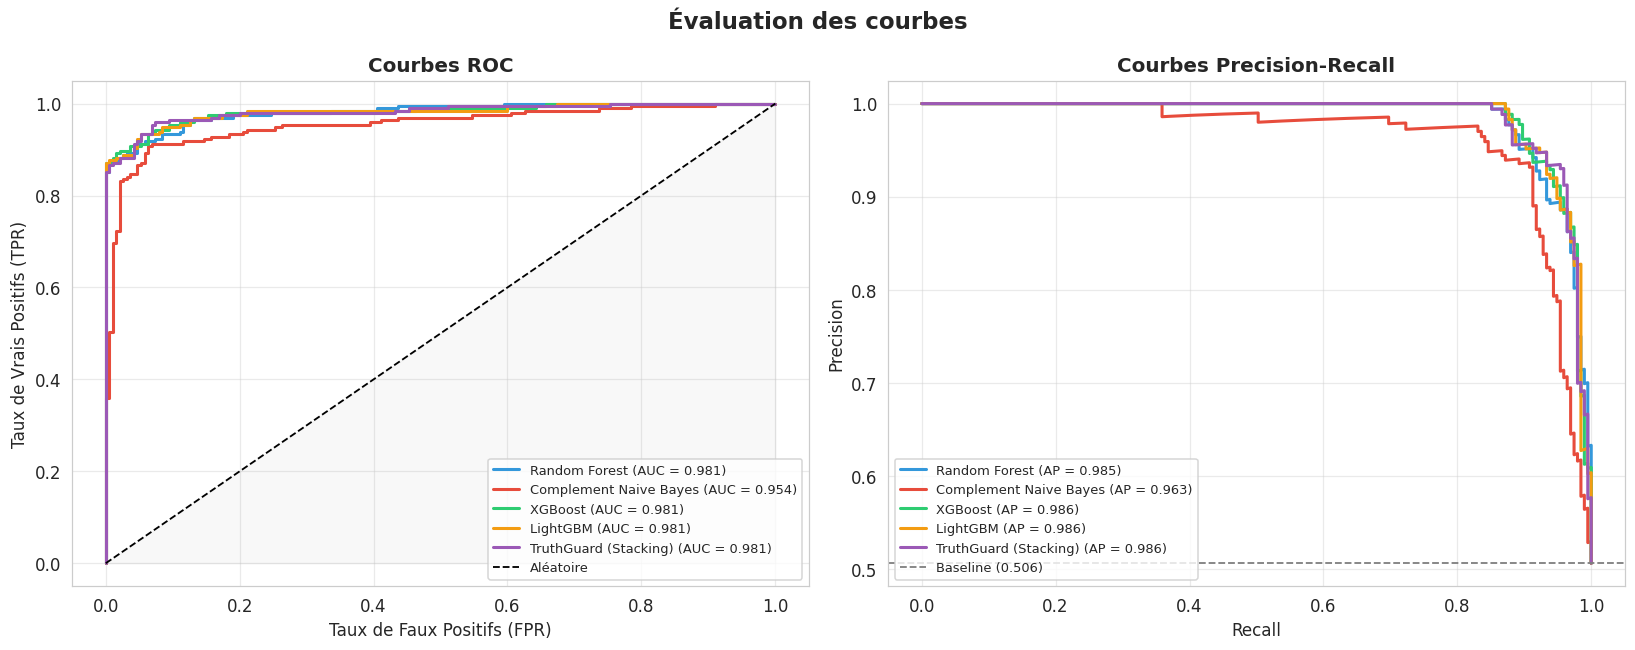

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette_roc = ["#3498db","#e74c3c","#2ecc71","#f39c12","#9b59b6","#1abc9c"]

for idx, (name, proba) in enumerate(ALL_PROBAS.items()):
    color = palette_roc[idx % len(palette_roc)]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name} (AUC = {roc_auc:.3f})")

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, lw=2, color=color,
                 label=f"{name} (AP = {ap:.3f})")

# ── ROC ──
axes[0].plot([0,1],[0,1],"k--",lw=1.2,label="Aléatoire")
axes[0].fill_between([0,1],[0,1], alpha=0.05, color="gray")
axes[0].set_title("Courbes ROC", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Taux de Faux Positifs (FPR)")
axes[0].set_ylabel("Taux de Vrais Positifs (TPR)")
axes[0].legend(loc="lower right", fontsize=8.5)
axes[0].grid(alpha=0.4)

# ── Precision-Recall ──
baseline_pr = y_test.mean()
axes[1].axhline(y=baseline_pr, color="gray", linestyle="--", lw=1.2,
                label=f"Baseline ({baseline_pr:.3f})")
axes[1].set_title("Courbes Precision-Recall", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left", fontsize=8.5)
axes[1].grid(alpha=0.4)

plt.suptitle("Évaluation des courbes", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 21. Analyse des erreurs (Faux Positifs & Faux Négatifs)

In [ ]:
# ── Analyse des erreurs sur le meilleur modèle (TruthGuard) ───────────────────
y_pred_tg = tg_meta.predict(test_meta)

# Reconstruire le dataframe de test
if "split" in df.columns:
    df_test_full = df[df["split"] == "test"].copy().reset_index(drop=True)
else:
    df_test_full = df.iloc[X_test_text.index].copy().reset_index(drop=True)

df_test_full["y_true"]  = y_test.values
df_test_full["y_pred"]  = y_pred_tg
df_test_full["y_proba"] = y_proba_tg

FP = df_test_full[(df_test_full["y_true"]==0) & (df_test_full["y_pred"]==1)]  # Fake prédit Real
FN = df_test_full[(df_test_full["y_true"]==1) & (df_test_full["y_pred"]==0)]  # Real prédit Fake
TP = df_test_full[(df_test_full["y_true"]==1) & (df_test_full["y_pred"]==1)]
TN = df_test_full[(df_test_full["y_true"]==0) & (df_test_full["y_pred"]==0)]

print("═" * 50)
print(f" Vrais Positifs  (TP) : {len(TP):>5}")
print(f" Vrais Négatifs  (TN) : {len(TN):>5}")
print(f" Faux Positifs   (FP) : {len(FP):>5}  ← Fake classifié comme Real")
print(f" Faux Négatifs   (FN) : {len(FN):>5}  ← Real classifié comme Fake")
print("═" * 50)

══════════════════════════════════════════════════
 Vrais Positifs  (TP) :   184
 Vrais Négatifs  (TN) :   177
 Faux Positifs   (FP) :    13  ← Fake classifié comme Real
 Faux Négatifs   (FN) :    11  ← Real classifié comme Fake
══════════════════════════════════════════════════


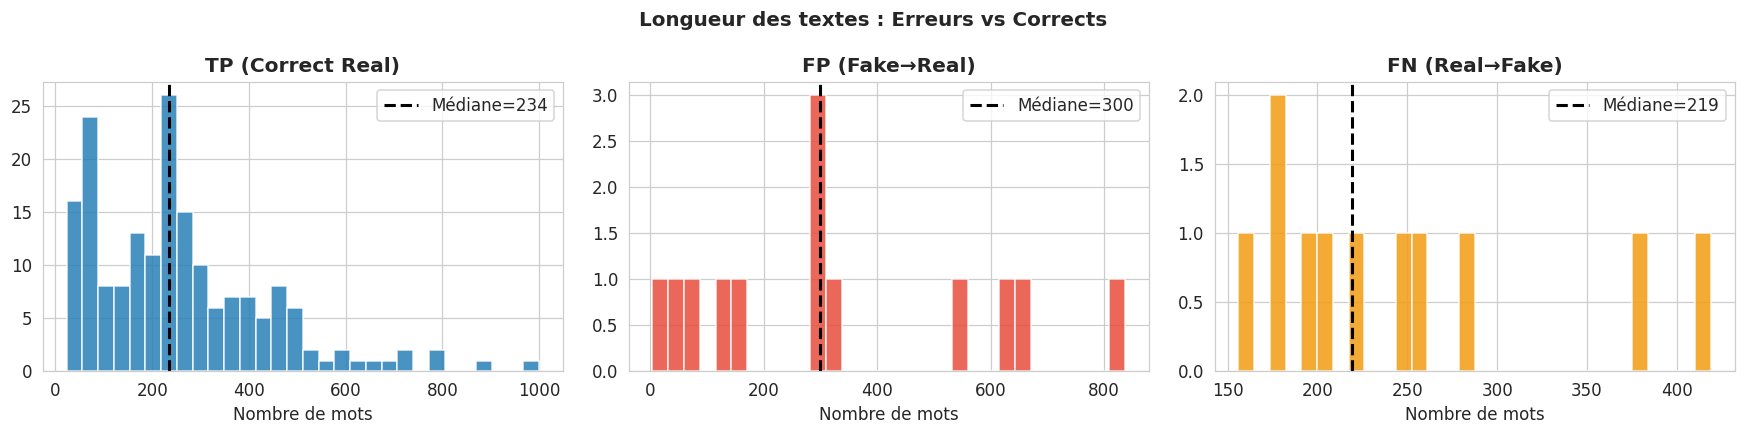


 Top 3 Faux Positifs les plus confiants (Fake → classifié Real) :
  [conf=0.960] Ivanka Trump, Paul Ryan meet Story highlights House Speaker Paul Ryan and Donald Trump have had a tense relationship thr...
  [conf=0.940] Paul Ryan defends Donald Trump, dodges on Machado comment Story highlights Trump on Tuesday defended calling former Miss...
  [conf=0.927] Kerry says Syrian diplomacy at impasse after truce collapses John Kerry says Washington cannot be successful alone. | AP...

 Top 3 Faux Négatifs les plus confiants (Real → classifié Fake) :
  [conf=0.982] Trump Jr. Once Again Shows His Lack Of Humanity With Disgusting Tweet About Syrian Refugees We’ve all seen the horrific ...
  [conf=0.977] Trump Won’t Tell America Where His Products Are Made, So Here’s A Handy Guide (IMAGES) Donald Trump constantly talks abo...
  [conf=0.975] Emmy Host Kimmel Calls Out Dude Who Made Trump A Reality TV Star For Helping Destroy America (VIDEO) 

8422 SHARES SHARE...


In [ ]:
# ── Longueur des textes d'erreurs vs corrects ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

groups = {
    "TP (Correct Real)": TP["clean_word_count"] if "clean_word_count" in TP.columns else TP["clean"].str.split().str.len(),
    "FP (Fake→Real)": FP["clean_word_count"] if "clean_word_count" in FP.columns else FP["clean"].str.split().str.len(),
    "FN (Real→Fake)": FN["clean_word_count"] if "clean_word_count" in FN.columns else FN["clean"].str.split().str.len(),
}
colors_g = ["#2980b9", "#e74c3c", "#f39c12"]

for ax, (name, data), color in zip(axes, groups.items(), colors_g):
    ax.hist(data.clip(upper=1000), bins=30, color=color, alpha=0.85)
    ax.axvline(data.median(), color="black", lw=2, linestyle="--",
               label=f"Médiane={data.median():.0f}")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Nombre de mots")
    ax.legend()

plt.suptitle("Longueur des textes : Erreurs vs Corrects", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Exemples d'erreurs les plus confiantes
print("\n Top 3 Faux Positifs les plus confiants (Fake → classifié Real) :")
for _, row in FP.nlargest(3, "y_proba").iterrows():
    print(f"  [conf={row['y_proba']:.3f}] {str(row.get('statement', row.get('clean','')))[:120]}...")

print("\n Top 3 Faux Négatifs les plus confiants (Real → classifié Fake) :")
for _, row in FN.nsmallest(3, "y_proba").iterrows():
    print(f"  [conf={1-row['y_proba']:.3f}] {str(row.get('statement', row.get('clean','')))[:120]}...")

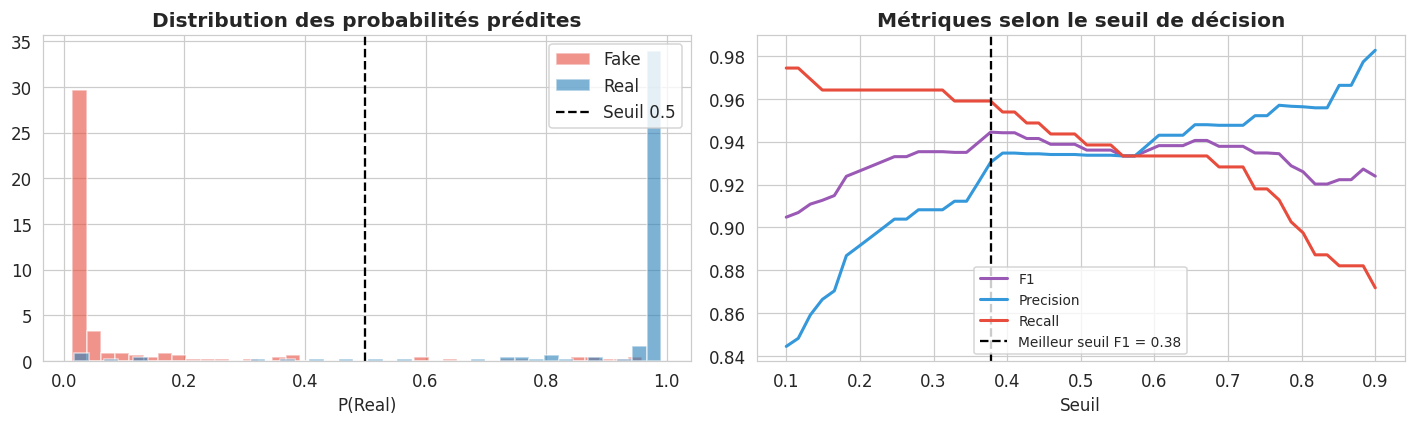

 Meilleur seuil F1 : 0.38  (F1 = 0.9444)


In [ ]:
# ── Distribution du score de confiance ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogramme des probas par classe réelle
for lbl, color, name in [(0, "#e74c3c", "Fake"), (1, "#2980b9", "Real")]:
    mask = df_test_full["y_true"] == lbl
    axes[0].hist(df_test_full[mask]["y_proba"], bins=40,
                 alpha=0.6, color=color, label=name, density=True)
axes[0].axvline(x=0.5, color="black", linestyle="--", lw=1.5, label="Seuil 0.5")
axes[0].set_title("Distribution des probabilités prédites", fontweight="bold")
axes[0].set_xlabel("P(Real)")
axes[0].legend()

# Erreurs selon le seuil de décision
thresholds = np.linspace(0.1, 0.9, 50)
f1s = [f1_score(df_test_full["y_true"], (df_test_full["y_proba"] >= t).astype(int))
       for t in thresholds]
precs = [precision_score(df_test_full["y_true"], (df_test_full["y_proba"] >= t).astype(int), zero_division=0)
         for t in thresholds]
recs = [recall_score(df_test_full["y_true"], (df_test_full["y_proba"] >= t).astype(int), zero_division=0)
        for t in thresholds]

axes[1].plot(thresholds, f1s,   color="#9b59b6", lw=2, label="F1")
axes[1].plot(thresholds, precs, color="#3498db", lw=2, label="Precision")
axes[1].plot(thresholds, recs,  color="#e74c3c", lw=2, label="Recall")
best_t = thresholds[np.argmax(f1s)]
axes[1].axvline(x=best_t, color="black", linestyle="--", lw=1.5,
                label=f"Meilleur seuil F1 = {best_t:.2f}")
axes[1].set_title("Métriques selon le seuil de décision", fontweight="bold")
axes[1].set_xlabel("Seuil")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f" Meilleur seuil F1 : {best_t:.2f}  (F1 = {max(f1s):.4f})")

---
## 22. Explicabilité SHAP

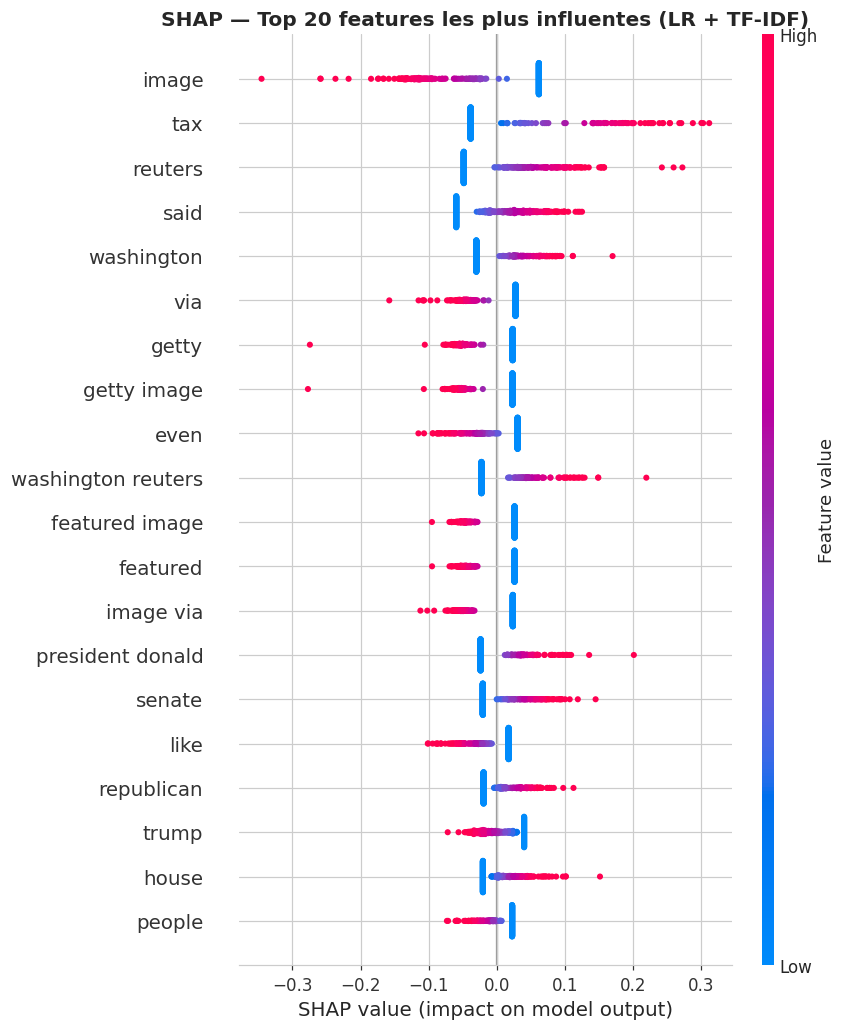

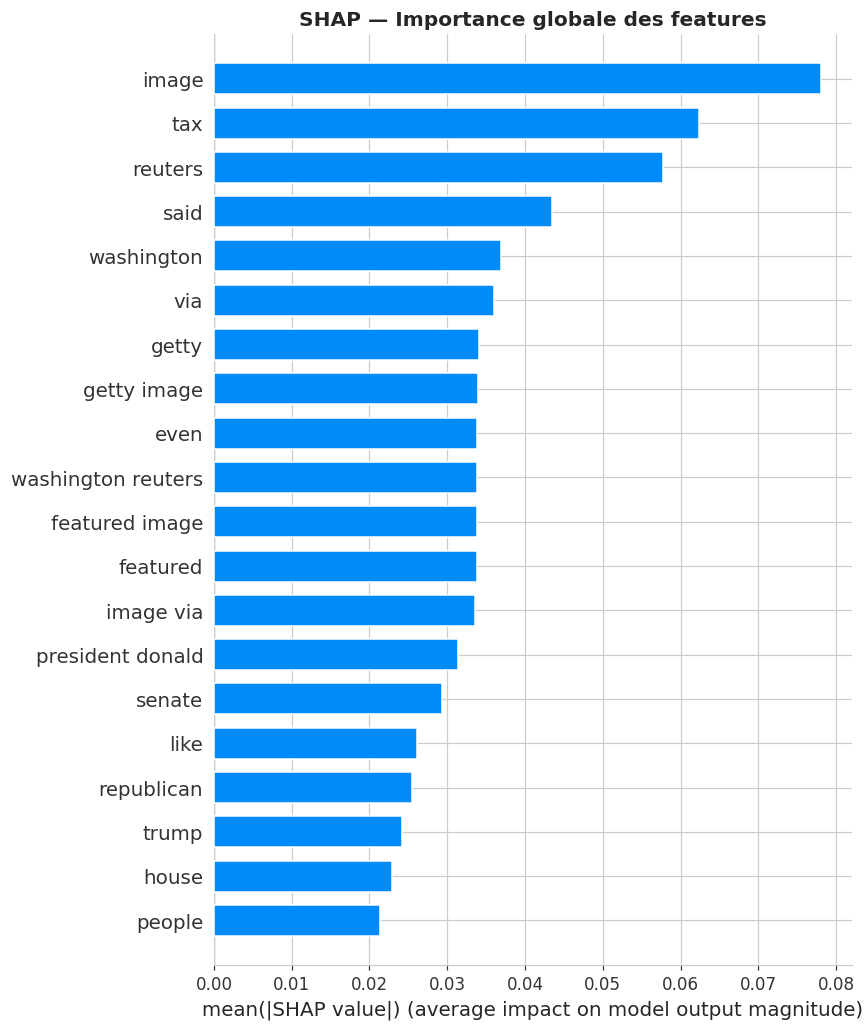


Explication locale — Faux Positif (idx=14) :


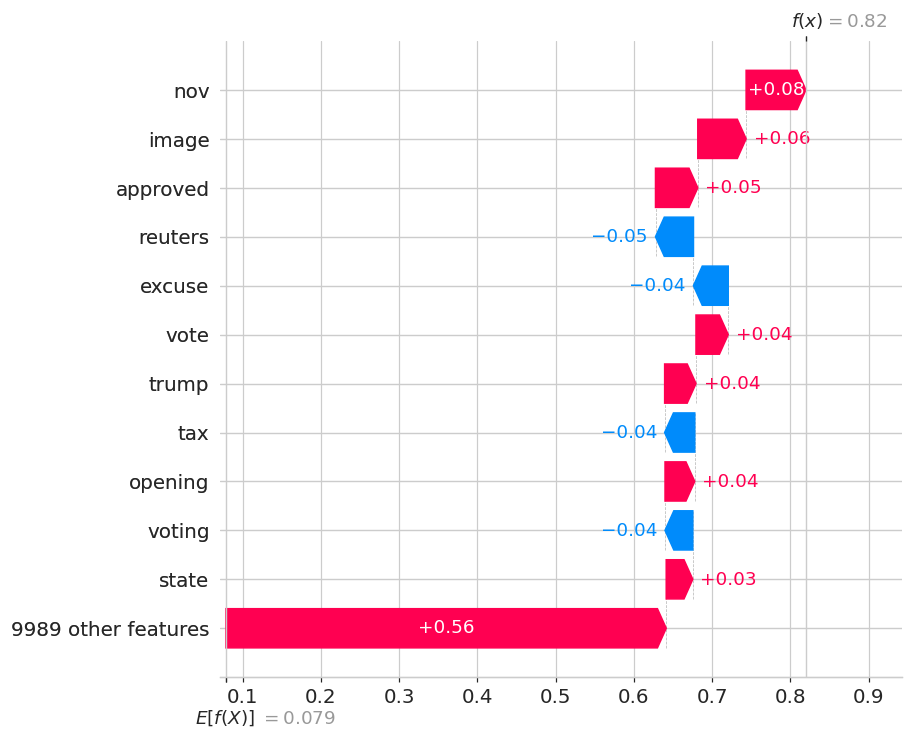

In [ ]:
try:
    import shap

    # LR sur TF-IDF word uniquement (features nommées)
    lr_explain = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    lr_explain.fit(X_train_word, y_train)

    explainer   = shap.LinearExplainer(lr_explain, X_train_word,
                                        feature_perturbation="interventional")
    N_EXPLAIN   = 300
    shap_values = explainer.shap_values(X_test_word[:N_EXPLAIN])
    feature_names = word_tfidf.get_feature_names_out()

    # ── Summary plot ──────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values, X_test_word[:N_EXPLAIN].toarray(),
        feature_names=feature_names,
        max_display=20, show=False
    )
    plt.title("SHAP — Top 20 features les plus influentes (LR + TF-IDF)",
              fontweight="bold")
    plt.tight_layout(); plt.show()

    # ── Bar plot global ───────────────────────────────────────────────────────
    plt.figure(figsize=(9, 5))
    shap.summary_plot(
        shap_values, X_test_word[:N_EXPLAIN].toarray(),
        feature_names=feature_names,
        max_display=20, plot_type="bar", show=False
    )
    plt.title("SHAP — Importance globale des features", fontweight="bold")
    plt.tight_layout(); plt.show()

    # ── Waterfall pour un FP et un FN ────────────────────────────────────────
    if len(FP) > 0:
        fp_local_idx = FP.index[0] % N_EXPLAIN
        print(f"\nExplication locale — Faux Positif (idx={FP.index[0]}) :")
        shap.plots._waterfall.waterfall_legacy(
            explainer.expected_value,
            shap_values[fp_local_idx],
            feature_names=feature_names,
            max_display=12, show=True
        )

except ImportError:
    print(" SHAP non installé : pip install shap --break-system-packages")

---
## 23. Évaluation cross-domain

In [ ]:
def cross_domain_eval(df_full, train_source, test_source):
    """Entraîne sur train_source, évalue sur test_source."""
    col = "clean" if "clean" in df_full.columns else "statement"
    df_tr = df_full[df_full["source_df"] == train_source].copy()
    df_te = df_full[df_full["source_df"] == test_source].copy()

    if df_tr.empty or df_te.empty:
        return None

    vec = TfidfVectorizer(max_features=10_000, ngram_range=(1,2), sublinear_tf=True)
    X_tr = vec.fit_transform(df_tr[col].fillna(""))
    X_te = vec.transform(df_te[col].fillna(""))

    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
    clf.fit(X_tr, df_tr["label"])
    y_pred = clf.predict(X_te)

    return {
        "Train":     train_source,
        "Test":      test_source,
        "F1":        f1_score(df_te["label"], y_pred, zero_division=0),
        "Accuracy":  accuracy_score(df_te["label"], y_pred),
        "AUC":       roc_auc_score(df_te["label"], clf.predict_proba(X_te)[:,1]),
    }

sources = df["source_df"].unique().tolist()
cross_results = [
    cross_domain_eval(df, src_tr, src_te)
    for src_tr in sources for src_te in sources if src_tr != src_te
]
cross_results = [r for r in cross_results if r is not None]
cross_df = pd.DataFrame(cross_results)

print(cross_df.round(4).to_string(index=False))

     Train       Test     F1  Accuracy    AUC
      isot   buzzfeed 0.3932    0.5943 0.6267
      isot politifact 0.2143    0.4211 0.4087
  buzzfeed       isot 0.7351    0.6573 0.8095
  buzzfeed politifact 0.6040    0.4825 0.5288
politifact       isot 0.3922    0.3097 0.2361
politifact   buzzfeed 0.5445    0.5029 0.5442


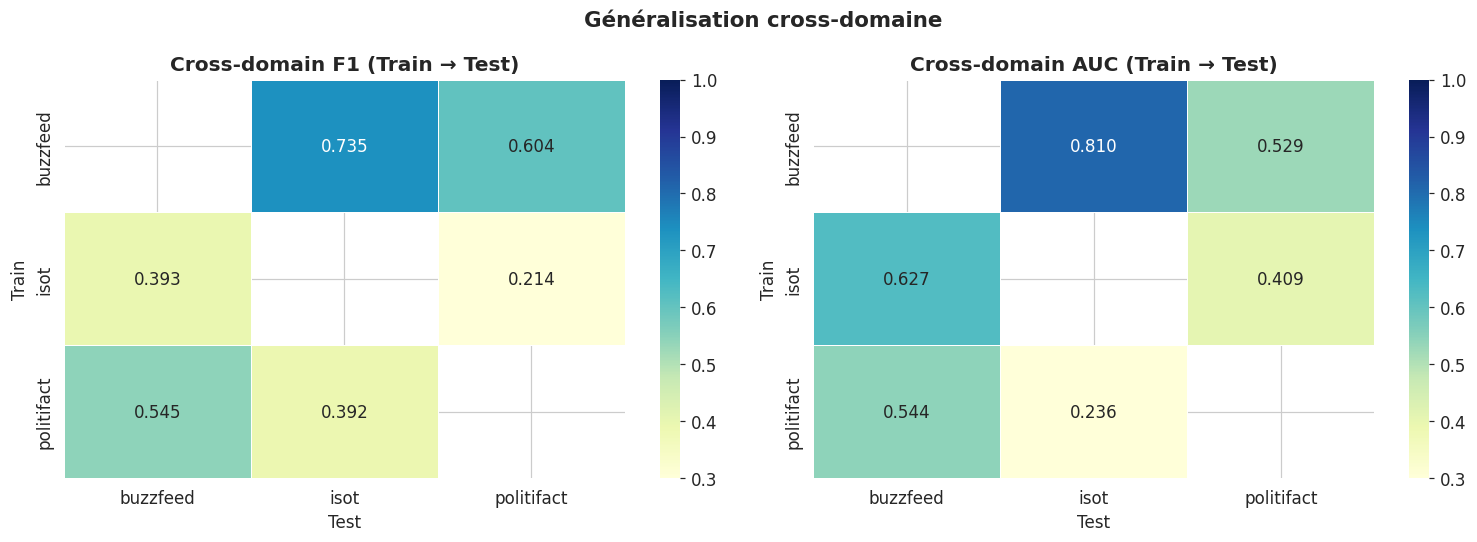


 Interprétation :
  F1 diagonale (même domaine) vs off-diagonal (cross-domain)
  F1 moyen cross-domain : 0.481
  F1 min  cross-domain  : 0.214
    Domain shift significatif — envisager du domain adaptation.


In [ ]:
if not cross_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric in zip(axes, ["F1", "AUC"]):
        pivot = cross_df.pivot(index="Train", columns="Test", values=metric)
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
                    vmin=0.3, vmax=1.0, linewidths=0.5, ax=ax)
        ax.set_title(f"Cross-domain {metric} (Train → Test)", fontweight="bold")

    plt.suptitle("Généralisation cross-domaine", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\n Interprétation :")
    print("  F1 diagonale (même domaine) vs off-diagonal (cross-domain)")
    print(f"  F1 moyen cross-domain : {cross_df['F1'].mean():.3f}")
    print(f"  F1 min  cross-domain  : {cross_df['F1'].min():.3f}")
    if cross_df['F1'].min() < 0.6:
        print("    Domain shift significatif — envisager du domain adaptation.")
    else:
        print("   Bonne généralisation cross-domain.")

---
## 24. Calibration des probabilités

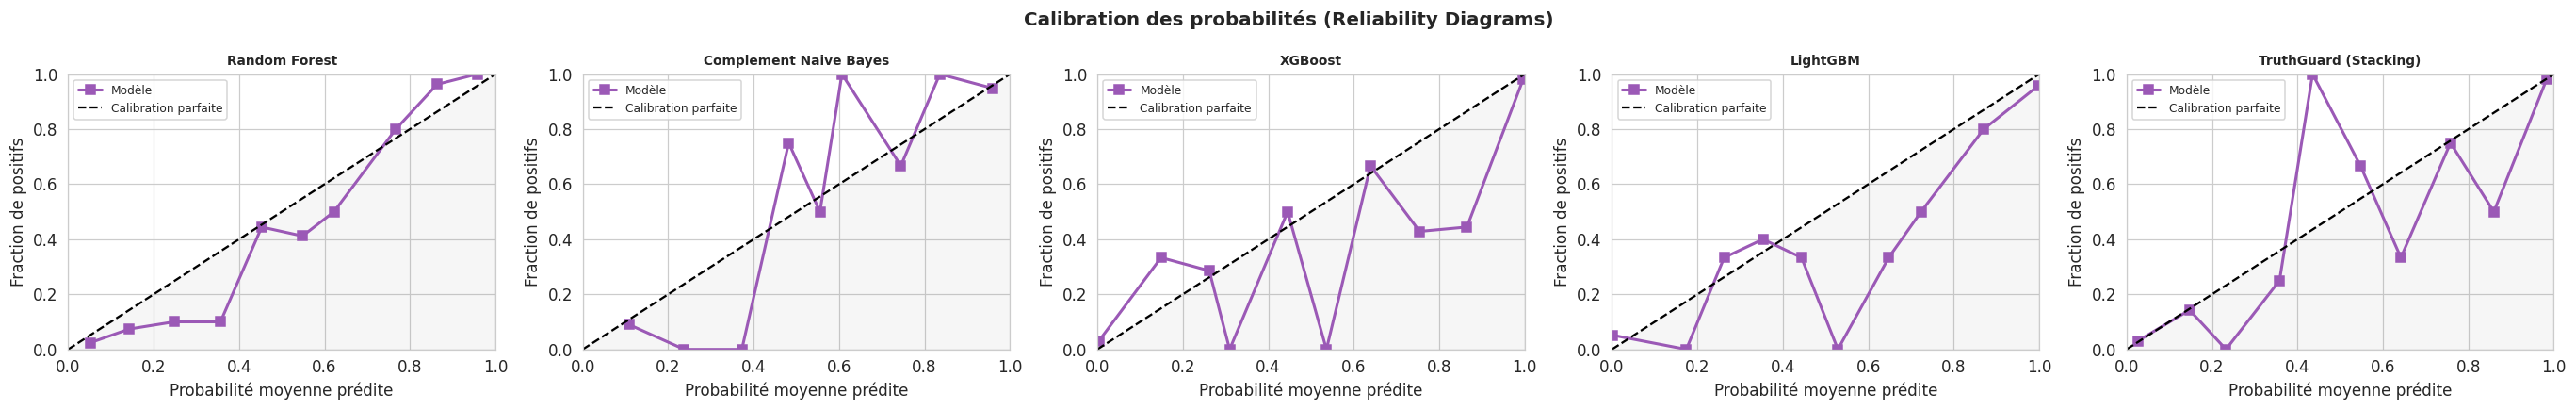

 Un modèle bien calibré a ses points proches de la diagonale.
   Si les points sont au-dessus → sous-confiant | En-dessous → sur-confiant.


In [ ]:
from sklearn.calibration import calibration_curve

# ── Reliability diagrams ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(ALL_PROBAS), figsize=(5 * len(ALL_PROBAS), 4))
if len(ALL_PROBAS) == 1:
    axes = [axes]

for ax, (name, proba) in zip(axes, ALL_PROBAS.items()):
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac_pos, "s-", color="#9b59b6", lw=2, label="Modèle")
    ax.plot([0,1],[0,1], "k--", lw=1.5, label="Calibration parfaite")
    ax.fill_between([0,1],[0,1], alpha=0.07, color="gray")
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.set_xlabel("Probabilité moyenne prédite")
    ax.set_ylabel("Fraction de positifs")
    ax.legend(fontsize=8)
    ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.suptitle("Calibration des probabilités (Reliability Diagrams)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(" Un modèle bien calibré a ses points proches de la diagonale.")
print("   Si les points sont au-dessus → sous-confiant | En-dessous → sur-confiant.")

 Cross-validation 5-fold sur Logistic Regression (TF-IDF + Embeddings)...

  F1  cross-val  : 0.9377 ± 0.0148
  AUC cross-val  : 0.9807 ± 0.0039


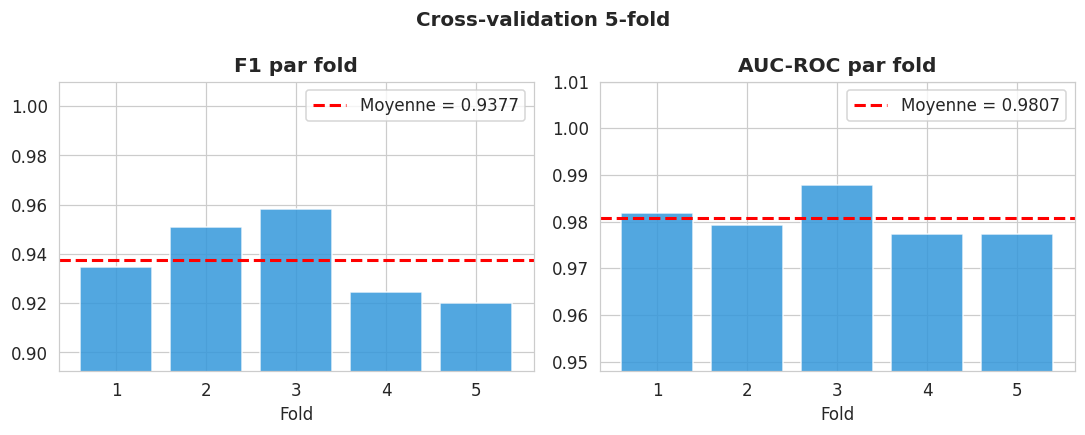

In [ ]:
from sklearn.model_selection import cross_val_score

# ── Validation croisée 5-fold sur le meilleur modèle ─────────────────────────
print(" Cross-validation 5-fold sur Logistic Regression (TF-IDF + Embeddings)...")
lr_cv = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_f1  = cross_val_score(lr_cv, X_train_full, y_train, cv=skf, scoring="f1",       n_jobs=-1)
cv_auc = cross_val_score(lr_cv, X_train_full, y_train, cv=skf, scoring="roc_auc",  n_jobs=-1)

print(f"\n  F1  cross-val  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"  AUC cross-val  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, scores, title in zip(axes, [cv_f1, cv_auc], ["F1 par fold", "AUC-ROC par fold"]):
    ax.bar(range(1, 6), scores, color="#3498db", alpha=0.85, edgecolor="white")
    ax.axhline(scores.mean(), color="red", lw=2, linestyle="--",
               label=f"Moyenne = {scores.mean():.4f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Fold")
    ax.set_ylim(scores.min() * 0.97, 1.01)
    ax.legend()

plt.suptitle("Cross-validation 5-fold", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 25. Sauvegarde du pipeline & prédiction libre

In [ ]:
import joblib

# ── Sauvegarde ────────────────────────────────────────────────────────────────
pipeline_path = CACHE_DIR / "truthguard_pipeline_v2.pkl"

joblib.dump({
    "word_vectorizer":  word_tfidf,
    "char_vectorizer":  char_tfidf,
    "base_models":      [base_lr, base_rf, base_svm],
    "base_names":       ["LR", "RF", "SVM"],
    "meta_model":       tg_meta,
    "best_threshold":   best_t,
    "results_summary":  results_df.to_dict(),
}, pipeline_path)

print(f" Pipeline sauvegardé : {pipeline_path}")

 Pipeline sauvegardé : /content/drive/MyDrive/cache_data/truthguard_pipeline_v2.pkl


In [ ]:
import re
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
import nltk
from sentence_transformers import SentenceTransformer
from scipy.sparse import hstack, csr_matrix
import numpy as np

# Download the specific resource if it's not already there
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

_STOP_WORDS = set(stopwords.words("english"))
_LEMMA      = WordNetLemmatizer()

# Load SentenceTransformer model once
model_st = SentenceTransformer("all-MiniLM-L6-v2")

def _get_wn_pos(tag):
    return (wordnet.ADJ if tag.startswith('J') else
            wordnet.VERB if tag.startswith('V') else
            wordnet.ADV  if tag.startswith('R') else wordnet.NOUN)

def _clean(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)     # URLs
    text = re.sub(r"<[^>]+>", " ", text)               # HTML
    text = re.sub(r"[^a-z\s]", " ", text)              # ponctuation / chiffres
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in _STOP_WORDS and len(t) > 2]
    tokens = [_LEMMA.lemmatize(w, _get_wn_pos(t)) for w, t in pos_tag(tokens)]
    return " ".join(tokens)

def predict_news(text: str, threshold: float = None) -> dict:
    """Prédit si un texte est une fake news avec niveau de confiance."""
    threshold = threshold or best_t
    cleaned   = _clean(text)

    # Word-level TF-IDF
    w_vec = word_tfidf.transform([cleaned])

    # Char-level TF-IDF
    c_vec = char_tfidf.transform([cleaned])

    # Combine TF-IDF features
    tfidf_combined_vec = hstack([w_vec, c_vec])

    # Generate embedding for the input text
    text_embedding = model_st.encode([text])

    # Combine TF-IDF and embedding to match training feature set
    full_feature_vec = hstack([tfidf_combined_vec, csr_matrix(text_embedding)])

    # Méta-features
    meta = np.array([[m.predict_proba(full_feature_vec)[0, 1]
                      for m in [base_lr, base_rf, base_svm]]])
    proba = tg_meta.predict_proba(meta)[0, 1]
    label = " RÉEL" if proba >= threshold else " FAKE"

    # Niveau de confiance
    margin = abs(proba - threshold)
    if margin < 0.1:   confidence_level = "Incertain"
    elif margin < 0.3: confidence_level = "Modéré"
    else:              confidence_level = "Élevé"

    return {
        "label":            label,
        "proba_real":       round(proba, 4),
        "proba_fake":       round(1 - proba, 4),
        "confidence":       f"{max(proba, 1-proba)*100:.1f}%",
        "confidence_level": confidence_level,
        "seuil_utilise":    threshold,
    }


# ── Tests ─────────────────────────────────────────────────────────────────────
samples = [
    "Scientists confirm new vaccine shows 95% efficacy in clinical trials conducted across 10 countries.",
    "Breaking: Government secretly implanting microchips through COVID vaccines to control citizens!",
    "Federal Reserve raises interest rates by 25 basis points amid inflation concerns.",
    "SHOCKING: Celebrity admits to being part of global satanic conspiracy controlling world governments.",
]

print("═" * 70)
print(" DÉMONSTRATION — Prédiction en temps réel")
print("═" * 70)
for s in samples:
    result = predict_news(s)
    print(f"\n {s[:80]}...")
    print(f"   → {result['label']}")
    print(f"   P(Real)={result['proba_real']:.3f} | P(Fake)={result['proba_fake']:.3f}"
          f" | Confiance: {result['confidence']} ({result['confidence_level']})")
    print("─" * 70)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


══════════════════════════════════════════════════════════════════════
 DÉMONSTRATION — Prédiction en temps réel
══════════════════════════════════════════════════════════════════════

 Scientists confirm new vaccine shows 95% efficacy in clinical trials conducted a...
   →  RÉEL
   P(Real)=0.910 | P(Fake)=0.089 | Confiance: 91.1% (Élevé)
──────────────────────────────────────────────────────────────────────

 Breaking: Government secretly implanting microchips through COVID vaccines to co...
   →  RÉEL
   P(Real)=0.431 | P(Fake)=0.569 | Confiance: 56.9% (Incertain)
──────────────────────────────────────────────────────────────────────

 Federal Reserve raises interest rates by 25 basis points amid inflation concerns...
   →  RÉEL
   P(Real)=0.918 | P(Fake)=0.082 | Confiance: 91.8% (Élevé)
──────────────────────────────────────────────────────────────────────

 SHOCKING: Celebrity admits to being part of global satanic conspiracy controllin...
   →  RÉEL
   P(Real)=0.414 | P(Fake)=0.58

In [ ]:
# ── Récapitulatif final ───────────────────────────────────────────────────────
print("═" * 65)
print(" RÉCAPITULATIF FINAL")
print("═" * 65)

best_row = results_df[results_df["Features"]=="TF-IDF + Embeddings"].loc[
    results_df[results_df["Features"]=="TF-IDF + Embeddings"]["F1"].idxmax()
]
print(f"\n   Meilleur modèle : {best_row['Model']}")
print(f"     Accuracy  : {best_row['Accuracy']:.4f}")
print(f"     F1-Score  : {best_row['F1']:.4f}")
print(f"     AUC-ROC   : {best_row['AUC-ROC']:.4f}")
print(f"     AUC-PR    : {best_row['AUC-PR']:.4f}")
print(f"\n   Meilleur seuil de décision : {best_t:.2f}")
print(f"   Pipeline sauvegardé        : {pipeline_path}")
print("="*65)

═════════════════════════════════════════════════════════════════
 RÉCAPITULATIF FINAL
═════════════════════════════════════════════════════════════════

   Meilleur modèle : TruthGuard (Stacking)
     Accuracy  : 0.9377
     F1-Score  : 0.9388
     AUC-ROC   : 0.9813
     AUC-PR    : 0.9858

   Meilleur seuil de décision : 0.38
   Pipeline sauvegardé        : /content/drive/MyDrive/cache_data/truthguard_pipeline_v2.pkl


In [ ]:
import os

# Define the cache directory path
CACHE_DIR_PATH = '/content/drive/MyDrive/cache_data'

# Create the directory if it doesn't exist
if not os.path.exists(CACHE_DIR_PATH):
    os.makedirs(CACHE_DIR_PATH)
    print(f'Directory created: {CACHE_DIR_PATH}')
else:
    print(f'Directory already exists: {CACHE_DIR_PATH}')

Directory created: /content/drive/MyDrive/cache_data
